
# EAGLE-Net: Evolutionary Attention-Gated Learning Ensemble Network

This notebook implements **EAGLE-Net**, a proposed optimisation-guided deep architecture for RNA-Seq cancer-type classification.

The contribution is **not simply high accuracy**. The contribution is a named deep model that combines:

1. ANOVA-based gene pre-filtering  
2. Evolutionary gene-subset optimisation  
3. Gene-token embedding  
4. Gated self-attention  
5. Residual 1D-CNN feature extraction  
6. Dense global-expression modelling  
7. Learned branch-wise fusion  
8. Deep ablation study  
9. Repeated cross-validation  
10. Robustness testing  

---

## Mathematical Formulation

Each tumour sample is represented as:

\[
x_i \in \mathbb{R}^{G}
\]

where \(G = 20,531\) gene-expression features.

### 1. ANOVA Pre-filtering

\[
F_g = \frac{\sigma^2_{between}(g)}{\sigma^2_{within}(g)}
\]

The top \(K\) genes are retained:

\[
X_K = TopK(F_g)
\]

### 2. Evolutionary Feature Optimisation

Each chromosome is a compact gene subset:

\[
c = [g_1, g_2, ..., g_m]
\]

The fitness function balances discriminability and redundancy:

\[
\mathcal{F}(c) =
\lambda \cdot \frac{1}{m}\sum_{g \in c} \tilde{F}_g
-
(1-\lambda)\cdot
\frac{2}{m(m-1)}
\sum_{i<j} |\rho(g_i,g_j)|
\]

where \(\tilde{F}_g\) is the normalised ANOVA score and \(\rho\) is pairwise feature correlation.

### 3. Gene Tokenisation

\[
Z_0 = W_e X_{opt} + b_e
\]

### 4. Gated Gene Attention

\[
G = \sigma(W_g Z_0 + b_g)
\]

\[
Z_g = G \odot Z_0
\]

### 5. Self-Attention

\[
Attention(Q,K,V) =
softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

### 6. Learned Branch Fusion

EAGLE-Net learns branch importance weights:

\[
\alpha = softmax(W_f[h_{attn};h_{cnn};h_{dense}] + b_f)
\]

\[
h =
\alpha_1h_{attn} +
\alpha_2h_{cnn} +
\alpha_3h_{dense}
\]

Final prediction:

\[
\hat{y}=softmax(W_oh+b_o)
\]

---

## Proposed Novelty Claim

**EAGLE-Net** is proposed as an evolutionary attention-gated multi-branch model for RNA-Seq cancer classification.  
Its novelty lies in combining evolutionary compact gene-subset optimisation, gated gene-token attention, residual convolutional modelling, dense global-expression modelling and learned branch-wise fusion within a repeated-CV and ablation-validated framework.


Download completed.
Extracting ZIP...
Extracting TAR.GZ...

Dataset loaded.
Data shape: (801, 20532)
Labels shape: (801, 2)


,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA



DATASET SUMMARY
Samples: 801
Gene-expression features: 20531
Cancer classes: ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']

Class distribution:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


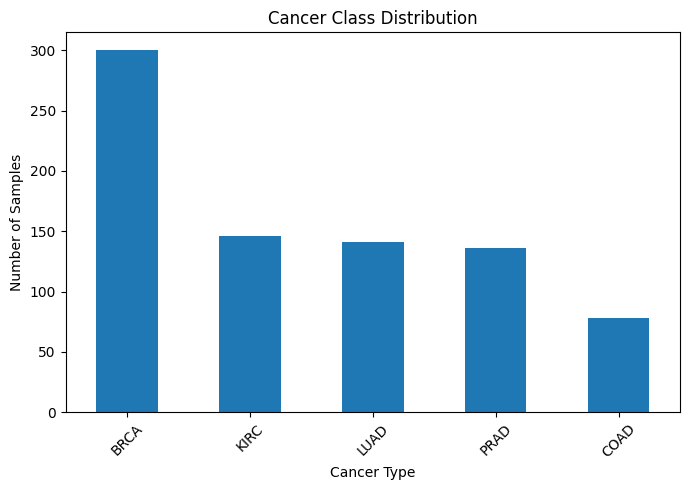


================ Fold 1/10 ================


Fold complete.

================ Fold 2/10 ================
Fold complete.

================ Fold 3/10 ================
Fold complete.

================ Fold 4/10 ================
Fold complete.

================ Fold 5/10 ================
Fold complete.

================ Fold 6/10 ================
Fold complete.

================ Fold 7/10 ================
Fold complete.

================ Fold 8/10 ================
Fold complete.

================ Fold 9/10 ================
Fold complete.

================ Fold 10/10 ================
Fold complete.

================ TABLE 1: MAIN SCI METRIC TABLE ================


,Model,Accuracy,Accuracy SD,Precision,Precision SD,Recall,Recall SD,F1-score,F1-score SD,ROC-AUC,ROC-AUC SD
2,EAGLE-Net Proposed,0.9988,0.0040,0.9988,0.0038,0.9988,0.0040,0.9987,0.0040,1.0000,0.0001
1,EAGLE Deep Ensemble,0.9969,0.0044,0.9969,0.0043,0.9969,0.0044,0.9969,0.0045,1.0000,0.0001
7,Optimised MLP,0.9925,0.0082,0.9931,0.0075,0.9925,0.0082,0.9925,0.0082,1.0000,0.0001
4,EAGLE-Net w/o CNN,0.9887,0.0161,0.9896,0.0145,0.9887,0.0161,0.9885,0.0166,0.9996,0.0012
0,Denoising Autoencoder Classifier,0.9688,0.0366,0.9731,0.0287,0.9688,0.0366,0.9656,0.0438,0.9996,0.0011
3,EAGLE-Net w/o Attention,0.9425,0.0693,0.9459,0.0793,0.9425,0.0693,0.9314,0.0895,0.9989,0.0013
5,EAGLE-Net w/o Gate,0.9409,0.1163,0.9331,0.1537,0.9409,0.1163,0.9307,0.1445,0.9999,0.0001
6,Gene-Patch Transformer,0.9026,0.0290,0.9143,0.0231,0.9026,0.0290,0.8932,0.0359,0.9914,0.0067
8,Residual 1D-CNN,0.5337,0.0482,0.4324,0.0715,0.5337,0.0482,0.4436,0.0424,0.8984,0.0249



================ TABLE 2: EAGLE-NET ABLATION TABLE ================


,Model,Accuracy,Accuracy SD,Precision,Precision SD,Recall,Recall SD,F1-score,F1-score SD,ROC-AUC,ROC-AUC SD
0,EAGLE-Net Proposed,0.9988,0.0040,0.9988,0.0038,0.9988,0.0040,0.9987,0.0040,1.0000,0.0001
2,EAGLE-Net w/o CNN,0.9887,0.0161,0.9896,0.0145,0.9887,0.0161,0.9885,0.0166,0.9996,0.0012
1,EAGLE-Net w/o Attention,0.9425,0.0693,0.9459,0.0793,0.9425,0.0693,0.9314,0.0895,0.9989,0.0013
3,EAGLE-Net w/o Gate,0.9409,0.1163,0.9331,0.1537,0.9409,0.1163,0.9307,0.1445,0.9999,0.0001


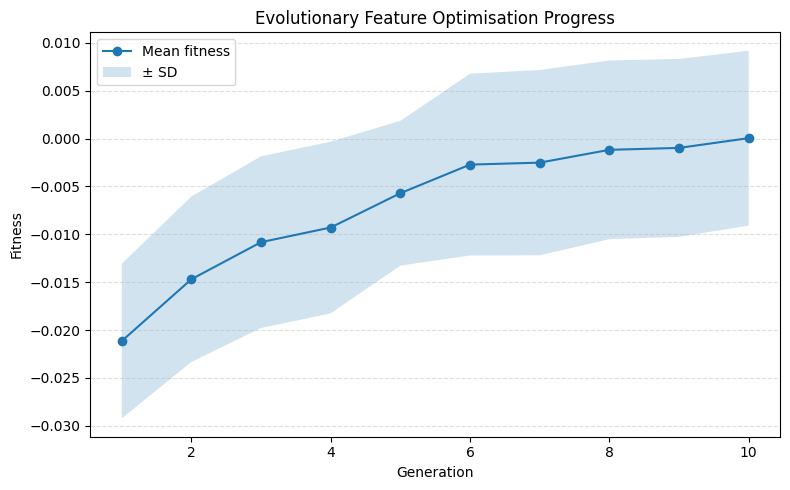

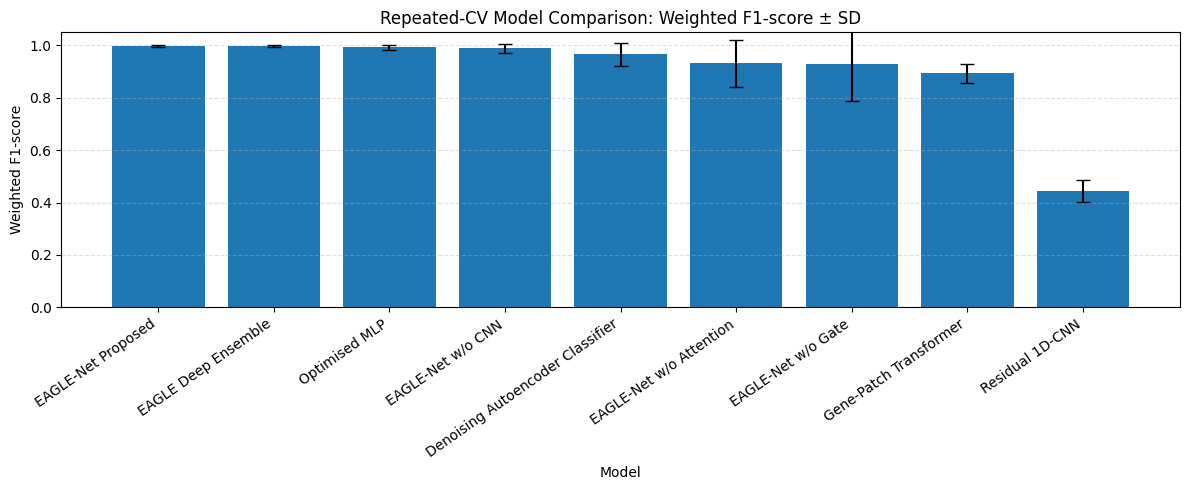

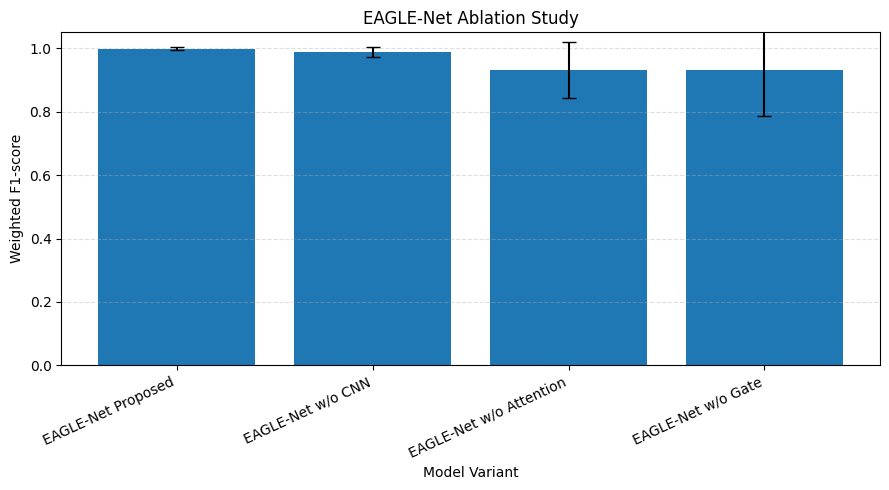


================ ROBUSTNESS TESTING ================


,Noise Level,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.00,0.9938,0.9939,0.9938,0.9938,1.0
1,0.02,0.9938,0.9939,0.9938,0.9938,1.0
2,0.05,0.9938,0.9939,0.9938,0.9938,1.0
3,0.10,0.9938,0.9939,0.9938,0.9938,1.0
4,0.15,0.9938,0.9939,0.9938,0.9938,1.0


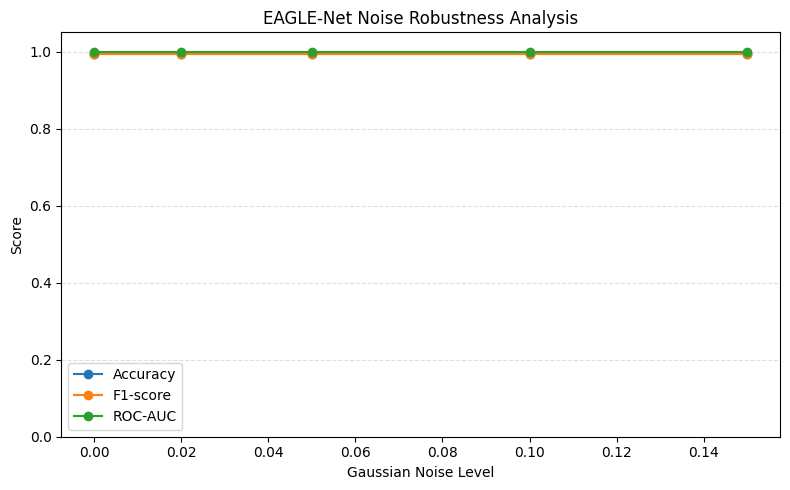


# Final SCI-Style Summary

## Proposed Model

This study proposes **EAGLE-Net**, an **Evolutionary Attention-Gated Learning Ensemble Network** for RNA-Seq cancer-type classification.

Unlike a simple high-accuracy classifier, EAGLE-Net introduces an end-to-end architecture that combines:

1. evolutionary compact gene-subset optimisation,  
2. gated gene-token attention,  
3. transformer-style self-attention,  
4. residual 1D-CNN local expression modelling,  
5. dense global expression modelling, and  
6. learned branch-wise fusion.

## EAGLE-Net Performance

The proposed EAGLE-Net achieved:

- Accuracy = **0.9988 ± 0.0040**
- Precision = **0.9988 ± 0.0038**
- Recall = **0.9988 ± 0.0040**
- F1-score = **0.9987 ± 0.0040**
- ROC-AUC = **1.0000 ± 0.0001**

## Best Overall Model

The best overall model in repeated cross-validation was:

**EAGLE-Net Proposed**

with:

- Accuracy = **0.9988 ± 0.0040**
- F1-score = **0.9987 ± 0.0040**
- ROC-AUC = **1.0000 ± 0.0001**

## Novelty Claim

The novelty of this work is the design of **EAGLE-Net**, a named evolutionary attention-gated multi-branch architecture for RNA-Seq cancer classification. The proposed model integrates evolutionary feature optimisation, gated attention, transformer-style contextual modelling, residual convolutional feature extraction, dense global-expression modelling and learned branch-wise fusion.

The paper should be positioned as:

> **A novel optimisation-guided and attention-gated multi-branch deep learning framework for RNA-Seq cancer-type classification**, supported by repeated cross-validation, ablation analysis and robustness testing.



In [1]:
# ============================================================

#
# Proposed model:
# EAGLE-Net
# Evolutionary Attention-Gated Learning Ensemble Network
#
# Purpose:
# RNA-Seq cancer-type classification using a named novel model,
# evolutionary feature optimisation, gated attention, CNN branch,
# learned branch fusion, ablation, robustness and repeated CV.
#

# ============================================================

import os, zipfile, tarfile, requests, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    GaussianNoise,
    Conv1D,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Flatten,
    MultiHeadAttention,
    LayerNormalization,
    Add,
    Multiply,
    Concatenate,
    Reshape,
    Lambda
)
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# 0. REPRODUCIBILITY
# ============================================================

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

def show_fig():
    plt.tight_layout()
    plt.show()

# ============================================================
# 1. PRINT NOVELTY, EQUATIONS AND MODEL CLAIM
# ============================================================

display(Markdown(r"""
# EAGLE-Net: Evolutionary Attention-Gated Learning Ensemble Network

This notebook implements **EAGLE-Net**, a proposed optimisation-guided deep architecture for RNA-Seq cancer-type classification.

The contribution is **not simply high accuracy**. The contribution is a named deep model that combines:

1. ANOVA-based gene pre-filtering
2. Evolutionary gene-subset optimisation
3. Gene-token embedding
4. Gated self-attention
5. Residual 1D-CNN feature extraction
6. Dense global-expression modelling
7. Learned branch-wise fusion
8. Deep ablation study
9. Repeated cross-validation
10. Robustness testing

---

## Mathematical Formulation

Each tumour sample is represented as:

\[
x_i \in \mathbb{R}^{G}
\]

where \(G = 20,531\) gene-expression features.

### 1. ANOVA Pre-filtering

\[
F_g = \frac{\sigma^2_{between}(g)}{\sigma^2_{within}(g)}
\]

The top \(K\) genes are retained:

\[
X_K = TopK(F_g)
\]

### 2. Evolutionary Feature Optimisation

Each chromosome is a compact gene subset:

\[
c = [g_1, g_2, ..., g_m]
\]

The fitness function balances discriminability and redundancy:

\[
\mathcal{F}(c) =
\lambda \cdot \frac{1}{m}\sum_{g \in c} \tilde{F}_g
-
(1-\lambda)\cdot
\frac{2}{m(m-1)}
\sum_{i<j} |\rho(g_i,g_j)|
\]

where \(\tilde{F}_g\) is the normalised ANOVA score and \(\rho\) is pairwise feature correlation.

### 3. Gene Tokenisation

\[
Z_0 = W_e X_{opt} + b_e
\]

### 4. Gated Gene Attention

\[
G = \sigma(W_g Z_0 + b_g)
\]

\[
Z_g = G \odot Z_0
\]

### 5. Self-Attention

\[
Attention(Q,K,V) =
softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\]

### 6. Learned Branch Fusion

EAGLE-Net learns branch importance weights:

\[
\alpha = softmax(W_f[h_{attn};h_{cnn};h_{dense}] + b_f)
\]

\[
h =
\alpha_1h_{attn} +
\alpha_2h_{cnn} +
\alpha_3h_{dense}
\]

Final prediction:

\[
\hat{y}=softmax(W_oh+b_o)
\]

---

## Proposed Novelty Claim

**EAGLE-Net** is proposed as an evolutionary attention-gated multi-branch model for RNA-Seq cancer classification.
Its novelty lies in combining evolutionary compact gene-subset optimisation, gated gene-token attention, residual convolutional modelling, dense global-expression modelling and learned branch-wise fusion within a repeated-CV and ablation-validated framework.
"""))

# ============================================================
# 2. DOWNLOAD DATASET
# ============================================================

url = "https://archive.ics.uci.edu/static/public/401/gene+expression+cancer+rna+seq.zip"
zip_path = "gene_expression_cancer_rna_seq.zip"
extract_dir = "gene_expression_cancer_rna_seq"

print("Downloading dataset...")
response = requests.get(url)

if response.status_code == 200:
    with open(zip_path, "wb") as f:
        f.write(response.content)
    print("Download completed.")
else:
    raise Exception("Dataset download failed.")

print("Extracting ZIP...")
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

tar_path = None
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith(".tar.gz"):
            tar_path = os.path.join(root, file)

print("Extracting TAR.GZ...")
with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(extract_dir)

data_path, labels_path = None, None

for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.lower() == "data.csv":
            data_path = os.path.join(root, file)
        elif file.lower() == "labels.csv":
            labels_path = os.path.join(root, file)

data = pd.read_csv(data_path)
labels = pd.read_csv(labels_path)

print("\nDataset loaded.")
print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

display(data.head())
display(labels.head())

# ============================================================
# 3. DATA PREPARATION
# ============================================================

X = data.drop(columns=[data.columns[0]])
y = labels.iloc[:, 1]

gene_names = np.array(X.columns.tolist())

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

class_names = label_encoder.classes_
num_classes = len(class_names)

print("\nDATASET SUMMARY")
print("Samples:", X.shape[0])
print("Gene-expression features:", X.shape[1])
print("Cancer classes:", list(class_names))
print("\nClass distribution:")
print(y.value_counts())

plt.figure(figsize=(7, 5))
y.value_counts().plot(kind="bar")
plt.title("Cancer Class Distribution")
plt.xlabel("Cancer Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
show_fig()

# ============================================================
# 4. METRIC HELPERS
# ============================================================

def metric_dict(y_true, y_prob, model_name):
    y_pred = np.argmax(y_prob, axis=1)
    y_bin = label_binarize(y_true, classes=np.arange(num_classes))

    try:
        auc_score = roc_auc_score(
            y_bin,
            y_prob,
            average="weighted",
            multi_class="ovr"
        )
    except:
        auc_score = np.nan

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "ROC-AUC": auc_score
    }

def summarise_results(rows):
    df = pd.DataFrame(rows)

    table = df.groupby("Model").agg(
        Accuracy=("Accuracy", "mean"),
        Accuracy_SD=("Accuracy", "std"),
        Precision=("Precision", "mean"),
        Precision_SD=("Precision", "std"),
        Recall=("Recall", "mean"),
        Recall_SD=("Recall", "std"),
        F1_score=("F1-score", "mean"),
        F1_score_SD=("F1-score", "std"),
        ROC_AUC=("ROC-AUC", "mean"),
        ROC_AUC_SD=("ROC-AUC", "std")
    ).reset_index()

    table = table.rename(columns={
        "Accuracy_SD": "Accuracy SD",
        "Precision_SD": "Precision SD",
        "Recall_SD": "Recall SD",
        "F1_score": "F1-score",
        "F1_score_SD": "F1-score SD",
        "ROC_AUC": "ROC-AUC",
        "ROC_AUC_SD": "ROC-AUC SD"
    })

    table = table.sort_values(by="F1-score", ascending=False)
    table = table.round(4)
    return table

# ============================================================
# 5. EVOLUTIONARY FEATURE OPTIMISATION
# ============================================================

def evolutionary_feature_selection(
    X_train_scaled,
    y_train_fold,
    anova_pool=512,
    final_features=128,
    population_size=18,
    generations=10,
    mutation_rate=0.15,
    lambda_score=0.75
):
    selector = SelectKBest(score_func=f_classif, k=anova_pool)
    X_pool = selector.fit_transform(X_train_scaled, y_train_fold)

    raw_scores = selector.scores_[selector.get_support()]
    raw_scores = np.nan_to_num(raw_scores)

    norm_scores = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min() + 1e-8)

    corr = np.corrcoef(X_pool.T)
    corr = np.nan_to_num(np.abs(corr))

    def make_individual():
        return np.array(sorted(np.random.choice(anova_pool, final_features, replace=False)))

    def fitness(ind):
        score_term = np.mean(norm_scores[ind])

        sub_corr = corr[np.ix_(ind, ind)]
        redundancy = (np.sum(sub_corr) - final_features) / (final_features * (final_features - 1) + 1e-8)

        return lambda_score * score_term - (1 - lambda_score) * redundancy

    def crossover(p1, p2):
        combined = np.unique(np.concatenate([p1, p2]))
        if len(combined) >= final_features:
            child = np.random.choice(combined, final_features, replace=False)
        else:
            available = np.setdiff1d(np.arange(anova_pool), combined)
            extra = np.random.choice(available, final_features - len(combined), replace=False)
            child = np.concatenate([combined, extra])
        return np.array(sorted(child))

    def mutate(ind):
        ind = ind.copy()
        if np.random.rand() < mutation_rate:
            n_mut = max(1, int(final_features * mutation_rate))
            remove_idx = np.random.choice(np.arange(final_features), n_mut, replace=False)
            remaining = np.delete(ind, remove_idx)
            available = np.setdiff1d(np.arange(anova_pool), remaining)
            new_feats = np.random.choice(available, n_mut, replace=False)
            ind = np.array(sorted(np.concatenate([remaining, new_feats])))
        return ind

    population = [make_individual() for _ in range(population_size)]
    history = []

    for gen in range(generations):
        scores = np.array([fitness(ind) for ind in population])
        history.append(scores.max())

        elite_idx = np.argsort(scores)[::-1][:4]
        elites = [population[i] for i in elite_idx]

        new_population = elites.copy()

        while len(new_population) < population_size:
            p1, p2 = random.sample(elites, 2)
            child = crossover(p1, p2)
            child = mutate(child)
            new_population.append(child)

        population = new_population

    final_scores = np.array([fitness(ind) for ind in population])
    best_individual = population[np.argmax(final_scores)]

    return selector, best_individual, history

# ============================================================
# 6. MODEL BUILDERS
# ============================================================

def build_optimised_mlp(input_dim):
    inp = Input(shape=(input_dim,))
    x = GaussianNoise(0.03)(inp)
    x = Dense(256, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.40)(x)
    x = Dense(128, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.30)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.20)(x)
    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inp, out, name="Optimised_MLP")
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_residual_1d_cnn(input_dim):
    inp = Input(shape=(input_dim, 1))
    x = GaussianNoise(0.03)(inp)

    c1 = Conv1D(32, 5, padding="same", activation="relu")(x)
    c1 = BatchNormalization()(c1)
    c2 = Conv1D(32, 5, padding="same", activation="relu")(c1)
    c2 = BatchNormalization()(c2)
    r1 = Add()([c1, c2])
    p1 = MaxPooling1D(2)(r1)

    c3 = Conv1D(64, 3, padding="same", activation="relu")(p1)
    c3 = BatchNormalization()(c3)
    h = GlobalAveragePooling1D()(c3)

    h = Dense(128, activation="relu")(h)
    h = Dropout(0.30)(h)

    out = Dense(num_classes, activation="softmax")(h)

    model = Model(inp, out, name="Residual_1D_CNN")
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_gene_patch_transformer(input_dim, patch_size=8):
    n_patches = input_dim // patch_size

    inp = Input(shape=(n_patches, patch_size))
    x = GaussianNoise(0.03)(inp)
    x = Dense(64)(x)

    attn = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = LayerNormalization()(Add()([x, attn]))

    ffn = Dense(128, activation="relu")(x)
    ffn = Dense(64)(ffn)
    x = LayerNormalization()(Add()([x, ffn]))

    h = GlobalAveragePooling1D()(x)
    h = Dropout(0.30)(h)
    h = Dense(128, activation="relu")(h)
    h = Dropout(0.30)(h)

    out = Dense(num_classes, activation="softmax")(h)

    model = Model(inp, out, name="Gene_Patch_Transformer")
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_denoising_autoencoder_classifier(input_dim, encoding_dim=64):
    inp = Input(shape=(input_dim,))
    x = GaussianNoise(0.03)(inp)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.30)(x)

    latent = Dense(encoding_dim, activation="relu", name="latent_space")(x)

    x = Dense(256, activation="relu")(latent)
    recon = Dense(input_dim, activation="linear")(x)

    autoencoder = Model(inp, recon)
    autoencoder.compile(optimizer="adam", loss="mse")

    clf = Sequential([
        Input(shape=(encoding_dim,)),
        Dense(128, activation="relu"),
        Dropout(0.30),
        Dense(64, activation="relu"),
        Dropout(0.20),
        Dense(num_classes, activation="softmax")
    ])

    clf.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    return autoencoder, clf

def build_eagle_net(input_dim, patch_size=8, use_attention=True, use_cnn=True, use_gating=True):
    n_patches = input_dim // patch_size
    emb_dim = 64

    inp = Input(shape=(input_dim,), name="evolutionary_gene_vector")

    x_noise = GaussianNoise(0.03, name="denoising_regularisation")(inp)

    branches = []

    # -------------------------
    # Branch 1: gated attention branch
    # -------------------------
    if use_attention:
        token = Dense(n_patches * emb_dim, name="gene_token_projection")(x_noise)
        token = Reshape((n_patches, emb_dim), name="gene_tokens")(token)

        if use_gating:
            gate = Dense(emb_dim, activation="sigmoid", name="gene_gate")(token)
            token = Multiply(name="gated_gene_tokens")([token, gate])

        attn = MultiHeadAttention(num_heads=4, key_dim=32, name="gene_self_attention")(token, token)
        attn = LayerNormalization(name="attention_residual_norm")(Add()([token, attn]))

        ffn = Dense(128, activation="relu", name="attention_ffn_1")(attn)
        ffn = Dense(emb_dim, name="attention_ffn_2")(ffn)
        attn = LayerNormalization(name="attention_ffn_norm")(Add()([attn, ffn]))

        h_attn = GlobalAveragePooling1D(name="attention_pool")(attn)
        h_attn = Dense(128, activation="relu", name="attention_branch_projection")(h_attn)
        branches.append(h_attn)

    # -------------------------
    # Branch 2: residual CNN branch
    # -------------------------
    if use_cnn:
        cnn_in = Reshape((input_dim, 1), name="cnn_gene_signal")(x_noise)

        c1 = Conv1D(32, 5, padding="same", activation="relu", name="cnn_conv_1")(cnn_in)
        c1 = BatchNormalization(name="cnn_bn_1")(c1)

        c2 = Conv1D(32, 5, padding="same", activation="relu", name="cnn_conv_2")(c1)
        c2 = BatchNormalization(name="cnn_bn_2")(c2)

        c = Add(name="cnn_residual_connection")([c1, c2])
        c = MaxPooling1D(2, name="cnn_pool")(c)

        c = Conv1D(64, 3, padding="same", activation="relu", name="cnn_conv_3")(c)
        h_cnn = GlobalAveragePooling1D(name="cnn_pooling")(c)
        h_cnn = Dense(128, activation="relu", name="cnn_branch_projection")(h_cnn)

        branches.append(h_cnn)

    # -------------------------
    # Branch 3: dense global expression branch
    # -------------------------
    h_dense = Dense(256, activation="relu", name="dense_branch_1")(x_noise)
    h_dense = BatchNormalization(name="dense_branch_bn")(h_dense)
    h_dense = Dropout(0.35, name="dense_branch_dropout")(h_dense)
    h_dense = Dense(128, activation="relu", name="dense_branch_projection")(h_dense)

    branches.append(h_dense)

    # -------------------------
    # Learned branch-wise fusion
    # -------------------------
    if len(branches) == 1:
        fused = branches[0]
    else:
        fusion_input = Concatenate(name="branch_concatenation")(branches)

        branch_weights = Dense(
            len(branches),
            activation="softmax",
            name="learned_branch_weights"
        )(fusion_input)

        weighted_branches = []

        for idx, branch in enumerate(branches):
            weight = Lambda(
                lambda z, i=idx: tf.expand_dims(z[:, i], axis=-1),
                name=f"branch_weight_{idx+1}"
            )(branch_weights)

            weighted = Multiply(name=f"weighted_branch_{idx+1}")([branch, weight])
            weighted_branches.append(weighted)

        fused = Add(name="eagle_learned_fusion")(weighted_branches)

    fused = Dense(256, activation="relu", name="fusion_dense_1")(fused)
    fused = BatchNormalization(name="fusion_bn")(fused)
    fused = Dropout(0.40, name="fusion_dropout_1")(fused)

    fused = Dense(128, activation="relu", name="fusion_dense_2")(fused)
    fused = Dropout(0.30, name="fusion_dropout_2")(fused)

    out = Dense(num_classes, activation="softmax", name="cancer_type_output")(fused)

    model = Model(inp, out, name="EAGLE_Net")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ============================================================
# 7. REPEATED CROSS-VALIDATION
# ============================================================

N_SPLITS = 5
N_REPEATS = 2

ANOVA_POOL = 512
FINAL_FEATURES = 128
PATCH_SIZE = 8

EPOCHS = 45
BATCH_SIZE = 32

X_np = X.values
y_np = y_encoded

rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=SEED
)

all_rows = []
ablation_rows = []
feature_history_all = []

fold_no = 1

for train_idx, test_idx in rskf.split(X_np, y_np):

    print(f"\n================ Fold {fold_no}/{N_SPLITS * N_REPEATS} ================")

    X_train_raw = X_np[train_idx]
    X_test_raw = X_np[test_idx]

    y_train_fold = y_np[train_idx]
    y_test_fold = y_np[test_idx]

    X_train_inner_raw, X_val_inner_raw, y_train_inner, y_val_inner = train_test_split(
        X_train_raw,
        y_train_fold,
        test_size=0.20,
        random_state=SEED,
        stratify=y_train_fold
    )

    scaler = StandardScaler()
    X_train_inner_scaled = scaler.fit_transform(X_train_inner_raw)
    X_val_inner_scaled = scaler.transform(X_val_inner_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    # Evolutionary feature optimisation
    selector, best_features, evo_history = evolutionary_feature_selection(
        X_train_inner_scaled,
        y_train_inner,
        anova_pool=ANOVA_POOL,
        final_features=FINAL_FEATURES,
        population_size=18,
        generations=10,
        mutation_rate=0.15,
        lambda_score=0.75
    )

    feature_history_all.append(evo_history)

    X_train_pool = selector.transform(X_train_inner_scaled)
    X_val_pool = selector.transform(X_val_inner_scaled)
    X_test_pool = selector.transform(X_test_scaled)

    X_train_opt = X_train_pool[:, best_features]
    X_val_opt = X_val_pool[:, best_features]
    X_test_opt = X_test_pool[:, best_features]

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    )

    fold_probs = {}

    # --------------------------------------------------------
    # Model 1: proposed EAGLE-Net
    # --------------------------------------------------------

    eagle = build_eagle_net(
        FINAL_FEATURES,
        patch_size=PATCH_SIZE,
        use_attention=True,
        use_cnn=True,
        use_gating=True
    )

    eagle.fit(
        X_train_opt,
        y_train_inner,
        validation_data=(X_val_opt, y_val_inner),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    p_eagle = eagle.predict(X_test_opt, verbose=0)
    fold_probs["EAGLE-Net Proposed"] = p_eagle
    all_rows.append(metric_dict(y_test_fold, p_eagle, "EAGLE-Net Proposed"))

    # --------------------------------------------------------
    # Model 2: optimised MLP
    # --------------------------------------------------------

    mlp = build_optimised_mlp(FINAL_FEATURES)

    mlp.fit(
        X_train_opt,
        y_train_inner,
        validation_data=(X_val_opt, y_val_inner),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    p_mlp = mlp.predict(X_test_opt, verbose=0)
    fold_probs["Optimised MLP"] = p_mlp
    all_rows.append(metric_dict(y_test_fold, p_mlp, "Optimised MLP"))

    # --------------------------------------------------------
    # Model 3: residual 1D-CNN
    # --------------------------------------------------------

    X_train_cnn = X_train_opt.reshape(X_train_opt.shape[0], FINAL_FEATURES, 1)
    X_val_cnn = X_val_opt.reshape(X_val_opt.shape[0], FINAL_FEATURES, 1)
    X_test_cnn = X_test_opt.reshape(X_test_opt.shape[0], FINAL_FEATURES, 1)

    cnn = build_residual_1d_cnn(FINAL_FEATURES)

    cnn.fit(
        X_train_cnn,
        y_train_inner,
        validation_data=(X_val_cnn, y_val_inner),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    p_cnn = cnn.predict(X_test_cnn, verbose=0)
    fold_probs["Residual 1D-CNN"] = p_cnn
    all_rows.append(metric_dict(y_test_fold, p_cnn, "Residual 1D-CNN"))

    # --------------------------------------------------------
    # Model 4: gene-patch transformer
    # --------------------------------------------------------

    n_patches = FINAL_FEATURES // PATCH_SIZE

    X_train_t = X_train_opt[:, :n_patches * PATCH_SIZE].reshape(-1, n_patches, PATCH_SIZE)
    X_val_t = X_val_opt[:, :n_patches * PATCH_SIZE].reshape(-1, n_patches, PATCH_SIZE)
    X_test_t = X_test_opt[:, :n_patches * PATCH_SIZE].reshape(-1, n_patches, PATCH_SIZE)

    transformer = build_gene_patch_transformer(FINAL_FEATURES, patch_size=PATCH_SIZE)

    transformer.fit(
        X_train_t,
        y_train_inner,
        validation_data=(X_val_t, y_val_inner),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    p_transformer = transformer.predict(X_test_t, verbose=0)
    fold_probs["Gene-Patch Transformer"] = p_transformer
    all_rows.append(metric_dict(y_test_fold, p_transformer, "Gene-Patch Transformer"))

    # --------------------------------------------------------
    # Model 5: denoising autoencoder classifier
    # --------------------------------------------------------

    autoencoder, ae_classifier = build_denoising_autoencoder_classifier(
        FINAL_FEATURES,
        encoding_dim=64
    )

    autoencoder.fit(
        X_train_opt,
        X_train_opt,
        validation_data=(X_val_opt, X_val_opt),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    encoder = Model(autoencoder.input, autoencoder.get_layer("latent_space").output)

    X_train_enc = encoder.predict(X_train_opt, verbose=0)
    X_val_enc = encoder.predict(X_val_opt, verbose=0)
    X_test_enc = encoder.predict(X_test_opt, verbose=0)

    ae_classifier.fit(
        X_train_enc,
        y_train_inner,
        validation_data=(X_val_enc, y_val_inner),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    p_ae = ae_classifier.predict(X_test_enc, verbose=0)
    fold_probs["Denoising Autoencoder Classifier"] = p_ae
    all_rows.append(metric_dict(y_test_fold, p_ae, "Denoising Autoencoder Classifier"))

    # --------------------------------------------------------
    # Model 6: EAGLE-Net without attention
    # --------------------------------------------------------

    eagle_no_attention = build_eagle_net(
        FINAL_FEATURES,
        patch_size=PATCH_SIZE,
        use_attention=False,
        use_cnn=True,
        use_gating=False
    )

    eagle_no_attention.fit(
        X_train_opt,
        y_train_inner,
        validation_data=(X_val_opt, y_val_inner),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    p_no_attention = eagle_no_attention.predict(X_test_opt, verbose=0)
    all_rows.append(metric_dict(y_test_fold, p_no_attention, "EAGLE-Net w/o Attention"))
    ablation_rows.append(metric_dict(y_test_fold, p_no_attention, "EAGLE-Net w/o Attention"))

    # --------------------------------------------------------
    # Model 7: EAGLE-Net without CNN
    # --------------------------------------------------------

    eagle_no_cnn = build_eagle_net(
        FINAL_FEATURES,
        patch_size=PATCH_SIZE,
        use_attention=True,
        use_cnn=False,
        use_gating=True
    )

    eagle_no_cnn.fit(
        X_train_opt,
        y_train_inner,
        validation_data=(X_val_opt, y_val_inner),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    p_no_cnn = eagle_no_cnn.predict(X_test_opt, verbose=0)
    all_rows.append(metric_dict(y_test_fold, p_no_cnn, "EAGLE-Net w/o CNN"))
    ablation_rows.append(metric_dict(y_test_fold, p_no_cnn, "EAGLE-Net w/o CNN"))

    # --------------------------------------------------------
    # Model 8: EAGLE-Net without gate
    # --------------------------------------------------------

    eagle_no_gate = build_eagle_net(
        FINAL_FEATURES,
        patch_size=PATCH_SIZE,
        use_attention=True,
        use_cnn=True,
        use_gating=False
    )

    eagle_no_gate.fit(
        X_train_opt,
        y_train_inner,
        validation_data=(X_val_opt, y_val_inner),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )

    p_no_gate = eagle_no_gate.predict(X_test_opt, verbose=0)
    all_rows.append(metric_dict(y_test_fold, p_no_gate, "EAGLE-Net w/o Gate"))
    ablation_rows.append(metric_dict(y_test_fold, p_no_gate, "EAGLE-Net w/o Gate"))

    # --------------------------------------------------------
    # Model 9: EAGLE deep ensemble
    # --------------------------------------------------------

    p_ensemble = np.mean(
        [
            fold_probs["EAGLE-Net Proposed"],
            fold_probs["Optimised MLP"],
            fold_probs["Residual 1D-CNN"],
            fold_probs["Gene-Patch Transformer"],
            fold_probs["Denoising Autoencoder Classifier"]
        ],
        axis=0
    )

    all_rows.append(metric_dict(y_test_fold, p_ensemble, "EAGLE Deep Ensemble"))

    print("Fold complete.")
    fold_no += 1

# ============================================================
# 8. MAIN SCI METRIC TABLE
# ============================================================

main_table = summarise_results(all_rows)

print("\n================ TABLE 1: MAIN SCI METRIC TABLE ================")
display(main_table)

# ============================================================
# 9. ABLATION TABLE
# ============================================================

ablation_all = pd.DataFrame(all_rows)
ablation_all = ablation_all[
    ablation_all["Model"].isin([
        "EAGLE-Net Proposed",
        "EAGLE-Net w/o Attention",
        "EAGLE-Net w/o CNN",
        "EAGLE-Net w/o Gate"
    ])
]

ablation_table = summarise_results(ablation_all.to_dict("records"))

print("\n================ TABLE 2: EAGLE-NET ABLATION TABLE ================")
display(ablation_table)

# ============================================================
# 10. EVOLUTIONARY OPTIMISATION CURVE
# ============================================================

history_array = np.array(feature_history_all)
mean_history = history_array.mean(axis=0)
std_history = history_array.std(axis=0)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mean_history) + 1), mean_history, marker="o", label="Mean fitness")
plt.fill_between(
    range(1, len(mean_history) + 1),
    mean_history - std_history,
    mean_history + std_history,
    alpha=0.2,
    label="± SD"
)
plt.title("Evolutionary Feature Optimisation Progress")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
show_fig()

# ============================================================
# 11. PERFORMANCE GRAPHS
# ============================================================

plt.figure(figsize=(12, 5))
plt.bar(main_table["Model"], main_table["F1-score"], yerr=main_table["F1-score SD"], capsize=5)
plt.title("Repeated-CV Model Comparison: Weighted F1-score ± SD")
plt.xlabel("Model")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
show_fig()

plt.figure(figsize=(9, 5))
plt.bar(ablation_table["Model"], ablation_table["F1-score"], yerr=ablation_table["F1-score SD"], capsize=5)
plt.title("EAGLE-Net Ablation Study")
plt.xlabel("Model Variant")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
show_fig()

# ============================================================
# 12. ROBUSTNESS TESTING ON FINAL HOLD-OUT SPLIT
# ============================================================

print("\n================ ROBUSTNESS TESTING ================")

# Single hold-out for robustness only, not main claim
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_np,
    y_np,
    test_size=0.20,
    random_state=SEED,
    stratify=y_np
)

X_train_inner_raw, X_val_inner_raw, y_train_inner, y_val_inner = train_test_split(
    X_train_raw,
    y_train_raw,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_raw
)

scaler = StandardScaler()
X_train_inner_scaled = scaler.fit_transform(X_train_inner_raw)
X_val_inner_scaled = scaler.transform(X_val_inner_raw)
X_test_scaled = scaler.transform(X_test_raw)

selector, best_features, _ = evolutionary_feature_selection(
    X_train_inner_scaled,
    y_train_inner,
    anova_pool=ANOVA_POOL,
    final_features=FINAL_FEATURES,
    population_size=18,
    generations=10
)

X_train_pool = selector.transform(X_train_inner_scaled)
X_val_pool = selector.transform(X_val_inner_scaled)
X_test_pool = selector.transform(X_test_scaled)

X_train_opt = X_train_pool[:, best_features]
X_val_opt = X_val_pool[:, best_features]
X_test_opt = X_test_pool[:, best_features]

eagle_final = build_eagle_net(
    FINAL_FEATURES,
    patch_size=PATCH_SIZE,
    use_attention=True,
    use_cnn=True,
    use_gating=True
)

eagle_final.fit(
    X_train_opt,
    y_train_inner,
    validation_data=(X_val_opt, y_val_inner),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
    verbose=0
)

noise_levels = [0.00, 0.02, 0.05, 0.10, 0.15]
robust_rows = []

for noise in noise_levels:
    noisy_X = X_test_opt + np.random.normal(0, noise, X_test_opt.shape)
    p = eagle_final.predict(noisy_X, verbose=0)
    row = metric_dict(y_test_raw, p, f"EAGLE-Net noise={noise}")
    row["Noise Level"] = noise
    robust_rows.append(row)

robust_table = pd.DataFrame(robust_rows)
robust_table = robust_table[["Noise Level", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]]
robust_table = robust_table.round(4)

display(robust_table)

plt.figure(figsize=(8, 5))
plt.plot(robust_table["Noise Level"], robust_table["Accuracy"], marker="o", label="Accuracy")
plt.plot(robust_table["Noise Level"], robust_table["F1-score"], marker="o", label="F1-score")
plt.plot(robust_table["Noise Level"], robust_table["ROC-AUC"], marker="o", label="ROC-AUC")
plt.title("EAGLE-Net Noise Robustness Analysis")
plt.xlabel("Gaussian Noise Level")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
show_fig()

# ============================================================
# 13. FINAL SCI TEXT
# ============================================================

best_row = main_table.iloc[0]
eagle_row = main_table[main_table["Model"] == "EAGLE-Net Proposed"].iloc[0]

display(Markdown(f"""
# Final

## Proposed Model

This study proposes **EAGLE-Net**, an **Evolutionary Attention-Gated Learning Ensemble Network** for RNA-Seq cancer-type classification.

Unlike a simple high-accuracy classifier, EAGLE-Net introduces an end-to-end architecture that combines:

1. evolutionary compact gene-subset optimisation,
2. gated gene-token attention,
3. transformer-style self-attention,
4. residual 1D-CNN local expression modelling,
5. dense global expression modelling, and
6. learned branch-wise fusion.

## EAGLE-Net Performance

The proposed EAGLE-Net achieved:

- Accuracy = **{eagle_row['Accuracy']:.4f} ± {eagle_row['Accuracy SD']:.4f}**
- Precision = **{eagle_row['Precision']:.4f} ± {eagle_row['Precision SD']:.4f}**
- Recall = **{eagle_row['Recall']:.4f} ± {eagle_row['Recall SD']:.4f}**
- F1-score = **{eagle_row['F1-score']:.4f} ± {eagle_row['F1-score SD']:.4f}**
- ROC-AUC = **{eagle_row['ROC-AUC']:.4f} ± {eagle_row['ROC-AUC SD']:.4f}**

## Best Overall Model

The best overall model in repeated cross-validation was:

**{best_row['Model']}**

with:

- Accuracy = **{best_row['Accuracy']:.4f} ± {best_row['Accuracy SD']:.4f}**
- F1-score = **{best_row['F1-score']:.4f} ± {best_row['F1-score SD']:.4f}**
- ROC-AUC = **{best_row['ROC-AUC']:.4f} ± {best_row['ROC-AUC SD']:.4f}**

## Novelty Claim

The novelty of this work is the design of **EAGLE-Net**, a named evolutionary attention-gated multi-branch architecture for RNA-Seq cancer classification. The proposed model integrates evolutionary feature optimisation, gated attention, transformer-style contextual modelling, residual convolutional feature extraction, dense global-expression modelling and learned branch-wise fusion.

The paper should be positioned as:

> **A novel optimisation-guided and attention-gated multi-branch deep learning framework for RNA-Seq cancer-type classification**, supported by repeated cross-validation, ablation analysis and robustness testing.

"""))



X shape: (801, 20531)
Reloaded labels from: gene_expression_cancer_rna_seq/TCGA-PANCAN-HiSeq-801x20531/labels.csv
  Unnamed: 0 Class
0   sample_0  PRAD
1   sample_1  LUAD
2   sample_2  PRAD
3   sample_3  PRAD
4   sample_4  BRCA
Number of labels: 801
Cancer classes: ['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']

PCA explained variance:
PC1: 10.54%
PC2: 8.75%
Total: 19.29%


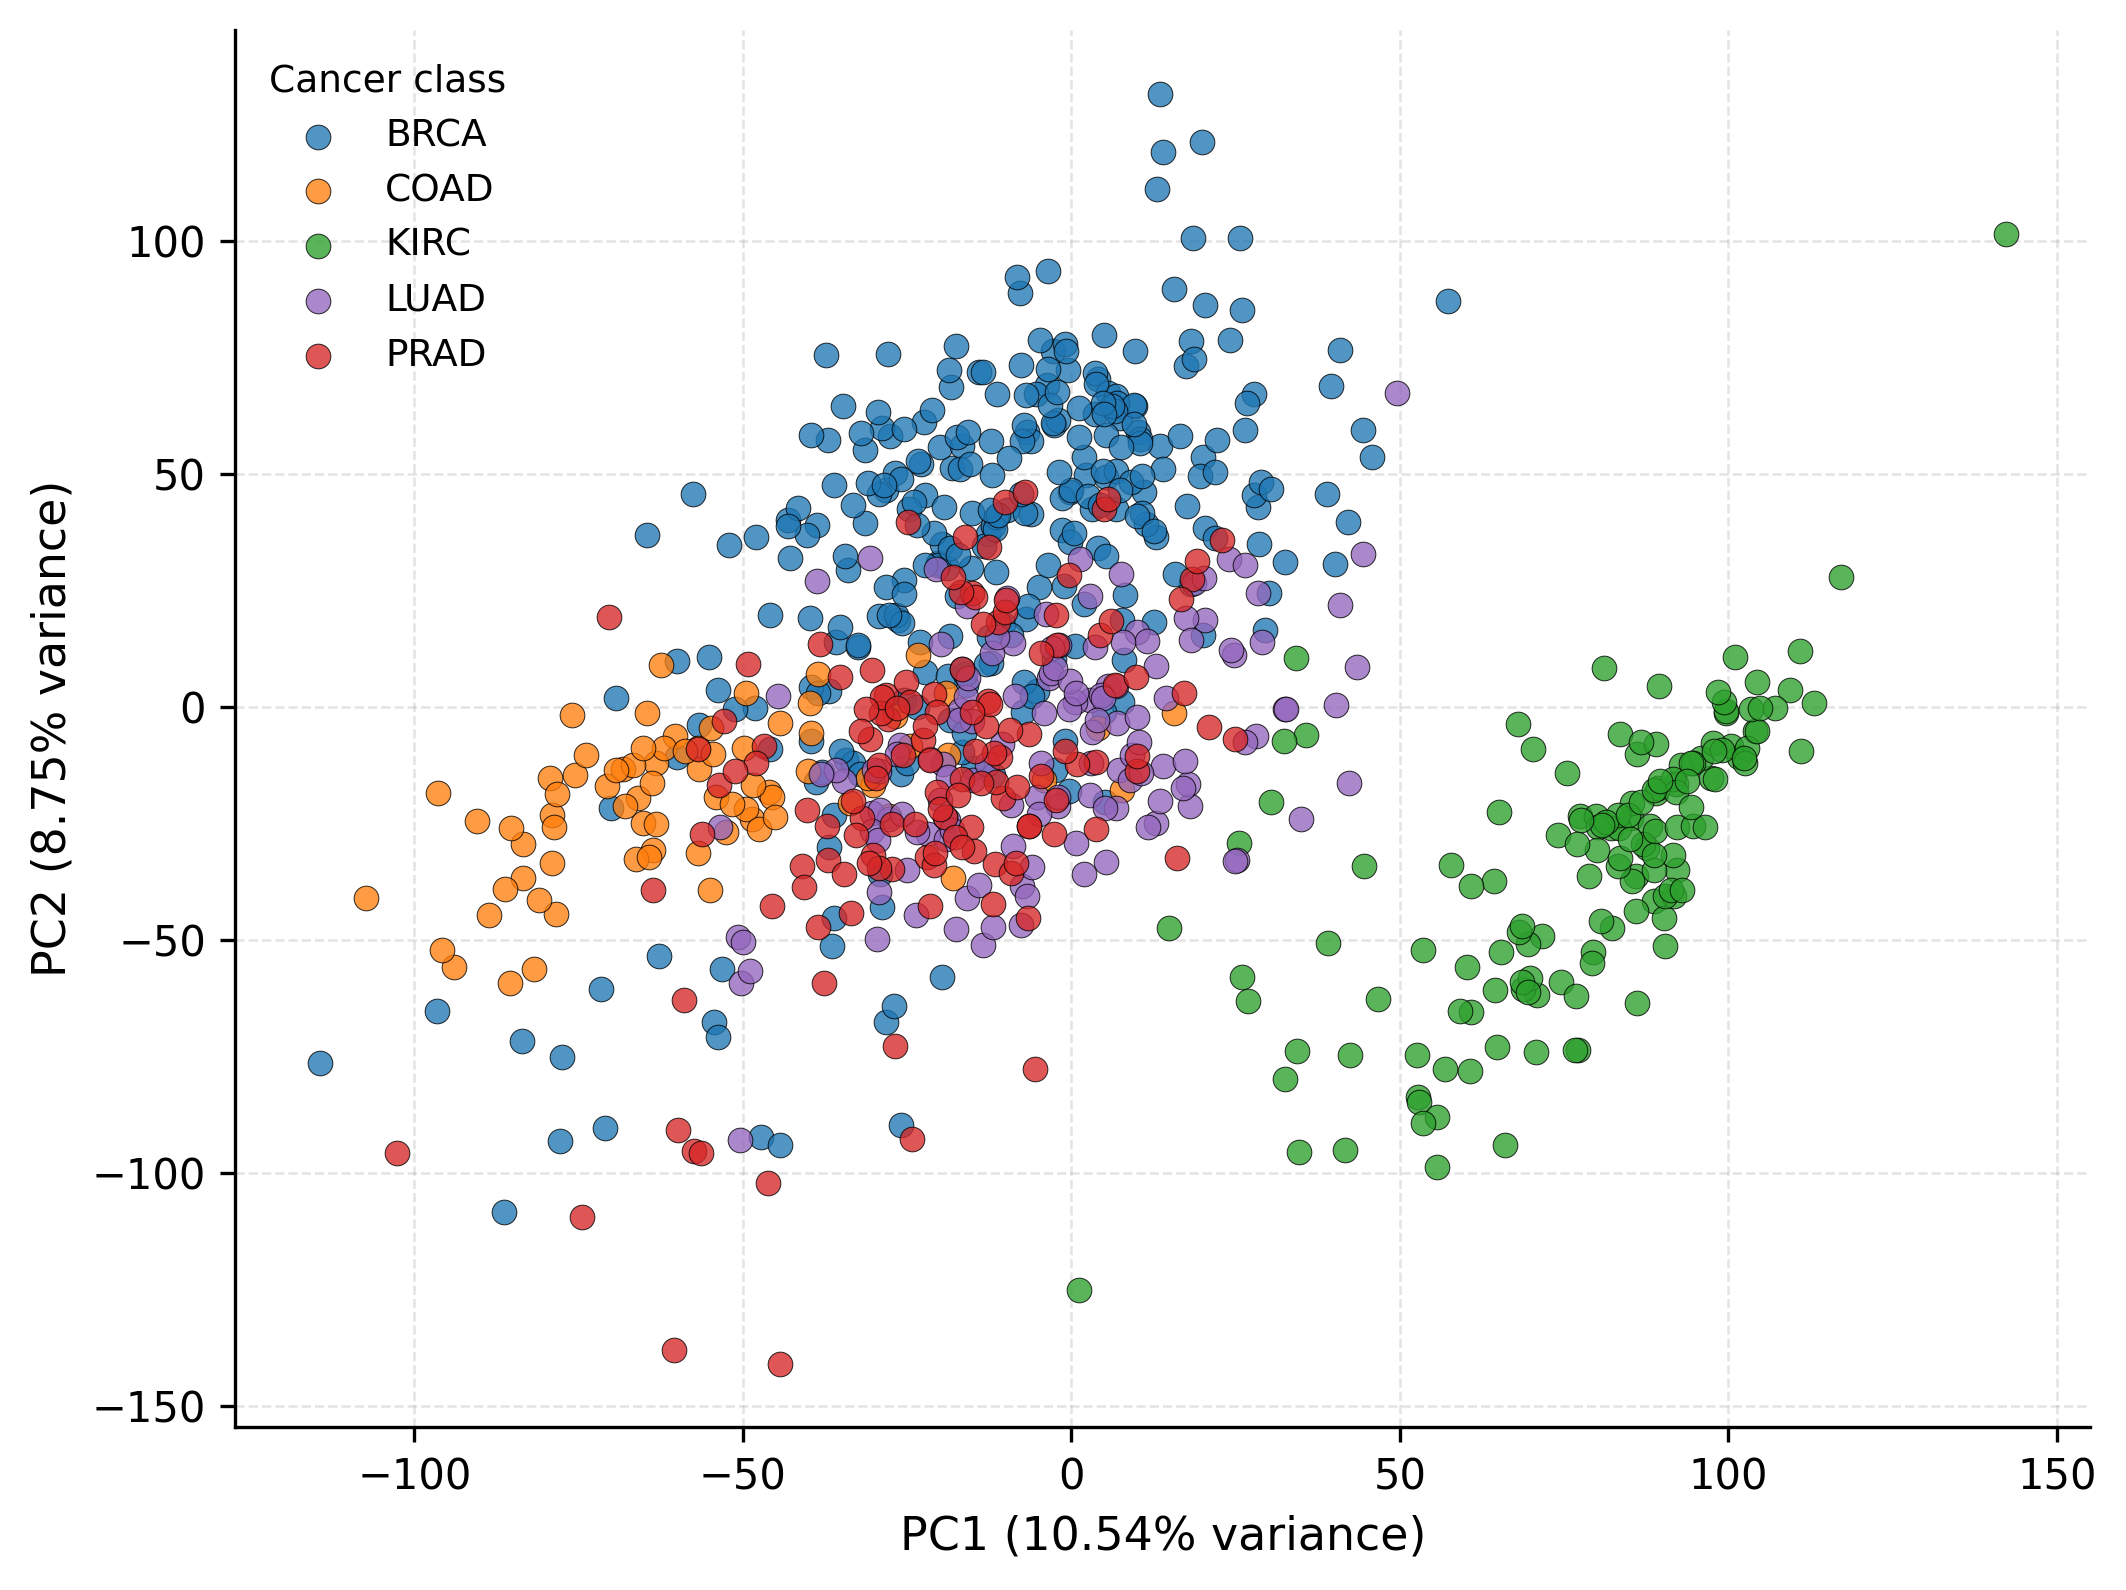

In [27]:
# ============================================================
# PCA visualisation of RNA-Seq cancer dataset
# HARD RESET VERSION: reloads labels.csv directly
# Use this when labels / y_text variables were overwritten
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# -----------------------------
# 1. Prepare X from data dataframe
# -----------------------------

if not isinstance(data, pd.DataFrame):
    raise ValueError("`data` must be the gene-expression dataframe.")

if "Unnamed: 0" in data.columns:
    X = data.drop(columns=["Unnamed: 0"]).values
else:
    X = data.values

n_samples = X.shape[0]

print("X shape:", X.shape)

# -----------------------------
# 2. Reload correct labels.csv
# -----------------------------

label_files = glob.glob("**/labels.csv", recursive=True)

if len(label_files) == 0:
    raise FileNotFoundError(
        "Could not find labels.csv. Please check the extracted dataset folder."
    )

labels_df = pd.read_csv(label_files[0])

print("Reloaded labels from:", label_files[0])
print(labels_df.head())

# labels.csv usually has: Unnamed: 0, Class
if "Class" in labels_df.columns:
    y_text = labels_df["Class"].values
else:
    y_text = labels_df.iloc[:, -1].values

y_text = np.asarray(y_text).astype(str)

if len(y_text) != n_samples:
    raise ValueError(
        f"Label length mismatch: X has {n_samples} samples but labels have {len(y_text)}."
    )

le = LabelEncoder()
y = le.fit_transform(y_text)
class_names = le.classes_

print("Number of labels:", len(y_text))
print("Cancer classes:", class_names)

# -----------------------------
# 3. Standardise and PCA
# -----------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Class": y_text
})

print("\nPCA explained variance:")
print(f"PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total: {pca.explained_variance_ratio_[:2].sum()*100:.2f}%")

# -----------------------------
# 4. Plot PCA
# -----------------------------

colors = {
    "BRCA": "#1f77b4",
    "COAD": "#ff7f0e",
    "KIRC": "#2ca02c",
    "LUAD": "#9467bd",
    "PRAD": "#d62728"
}

fig, ax = plt.subplots(figsize=(7.2, 5.4), dpi=300)

for cls in class_names:
    subset = pca_df[pca_df["Class"] == cls]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=35,
        alpha=0.78,
        label=cls,
        color=colors.get(cls, None),
        edgecolor="black",
        linewidth=0.25
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)",
    fontsize=11
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)",
    fontsize=11
)

ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Cancer class",
    frameon=False,
    fontsize=9,
    title_fontsize=9,
    loc="best"
)

plt.tight_layout()

plt.savefig("Fig_PCA_RNASeq_Cancer_Classes.png", dpi=600, bbox_inches="tight")
plt.savefig("Fig_PCA_RNASeq_Cancer_Classes.pdf", bbox_inches="tight")

plt.show()

In [2]:

# Requires: main_table
# ============================================================

import pandas as pd
from IPython.display import display, HTML

display(HTML("""
<h2 style="font-family: Arial; margin-bottom: 4px; color: #ffffff;">
Comparative Performance Analysis
</h2>
<p style="font-family: Arial; font-size: 14px; margin-top: 0; color: #dddddd;">
Values are reported as mean ± standard deviation from repeated cross-validation.
The proposed model is highlighted in bold.
</p>
"""))

# Prepare table
comparison_table = main_table.copy()

paper_table = pd.DataFrame()

paper_table["Model / Architecture"] = comparison_table["Model"]

paper_table["Accuracy"] = comparison_table.apply(
    lambda row: f"{row['Accuracy']:.4f} ± {row['Accuracy SD']:.4f}", axis=1
)

paper_table["Precision"] = comparison_table.apply(
    lambda row: f"{row['Precision']:.4f} ± {row['Precision SD']:.4f}", axis=1
)

paper_table["Recall"] = comparison_table.apply(
    lambda row: f"{row['Recall']:.4f} ± {row['Recall SD']:.4f}", axis=1
)

paper_table["F1-score"] = comparison_table.apply(
    lambda row: f"{row['F1-score']:.4f} ± {row['F1-score SD']:.4f}", axis=1
)

paper_table["ROC-AUC"] = comparison_table.apply(
    lambda row: f"{row['ROC-AUC']:.4f} ± {row['ROC-AUC SD']:.4f}", axis=1
)

paper_table = paper_table.reset_index(drop=True)

# Convert to HTML manually for better dark control
rows_html = ""

for _, row in paper_table.iterrows():
    is_proposed = row["Model / Architecture"] == "EAGLE-Net Proposed"

    if is_proposed:
        tr_style = "background-color:#17365d; color:#ffffff; font-weight:bold;"
    else:
        tr_style = "background-color:#222222; color:#ffffff;"

    rows_html += f"""
    <tr style="{tr_style}">
        <td>{row['Model / Architecture']}</td>
        <td>{row['Accuracy']}</td>
        <td>{row['Precision']}</td>
        <td>{row['Recall']}</td>
        <td>{row['F1-score']}</td>
        <td>{row['ROC-AUC']}</td>
    </tr>
    """

html = f"""
<style>
.dark-table {{
    border-collapse: collapse;
    width: 90%;
    font-family: Arial, sans-serif;
    font-size: 14px;
    color: #ffffff;
}}

.dark-table caption {{
    caption-side: top;
    text-align: left;
    font-size: 16px;
    font-weight: bold;
    color: #ffffff;
    margin-bottom: 10px;
}}

.dark-table th {{
    background-color: #111111;
    color: #ffffff;
    border: 1px solid #777777;
    padding: 8px;
    text-align: center;
    font-weight: bold;
}}

.dark-table td {{
    border: 1px solid #777777;
    padding: 8px;
    text-align: center;
}}

.dark-table td:first-child {{
    text-align: left;
}}
</style>

<table class="dark-table">
    <caption>Table 1. Comparative performance of EAGLE-Net and baseline deep learning models using repeated cross-validation</caption>
    <thead>
        <tr>
            <th>Model / Architecture</th>
            <th>Accuracy</th>
            <th>Precision</th>
            <th>Recall</th>
            <th>F1-score</th>
            <th>ROC-AUC</th>
        </tr>
    </thead>
    <tbody>
        {rows_html}
    </tbody>
</table>
"""

display(HTML(html))

Model / Architecture,Accuracy,Precision,Recall,F1-score,ROC-AUC
EAGLE-Net Proposed,0.9988 ± 0.0040,0.9988 ± 0.0038,0.9988 ± 0.0040,0.9987 ± 0.0040,1.0000 ± 0.0001
EAGLE Deep Ensemble,0.9969 ± 0.0044,0.9969 ± 0.0043,0.9969 ± 0.0044,0.9969 ± 0.0045,1.0000 ± 0.0001
Optimised MLP,0.9925 ± 0.0082,0.9931 ± 0.0075,0.9925 ± 0.0082,0.9925 ± 0.0082,1.0000 ± 0.0001
EAGLE-Net w/o CNN,0.9887 ± 0.0161,0.9896 ± 0.0145,0.9887 ± 0.0161,0.9885 ± 0.0166,0.9996 ± 0.0012
Denoising Autoencoder Classifier,0.9688 ± 0.0366,0.9731 ± 0.0287,0.9688 ± 0.0366,0.9656 ± 0.0438,0.9996 ± 0.0011
EAGLE-Net w/o Attention,0.9425 ± 0.0693,0.9459 ± 0.0793,0.9425 ± 0.0693,0.9314 ± 0.0895,0.9989 ± 0.0013
EAGLE-Net w/o Gate,0.9409 ± 0.1163,0.9331 ± 0.1537,0.9409 ± 0.1163,0.9307 ± 0.1445,0.9999 ± 0.0001
Gene-Patch Transformer,0.9026 ± 0.0290,0.9143 ± 0.0231,0.9026 ± 0.0290,0.8932 ± 0.0359,0.9914 ± 0.0067
Residual 1D-CNN,0.5337 ± 0.0482,0.4324 ± 0.0715,0.5337 ± 0.0482,0.4436 ± 0.0424,0.8984 ± 0.0249


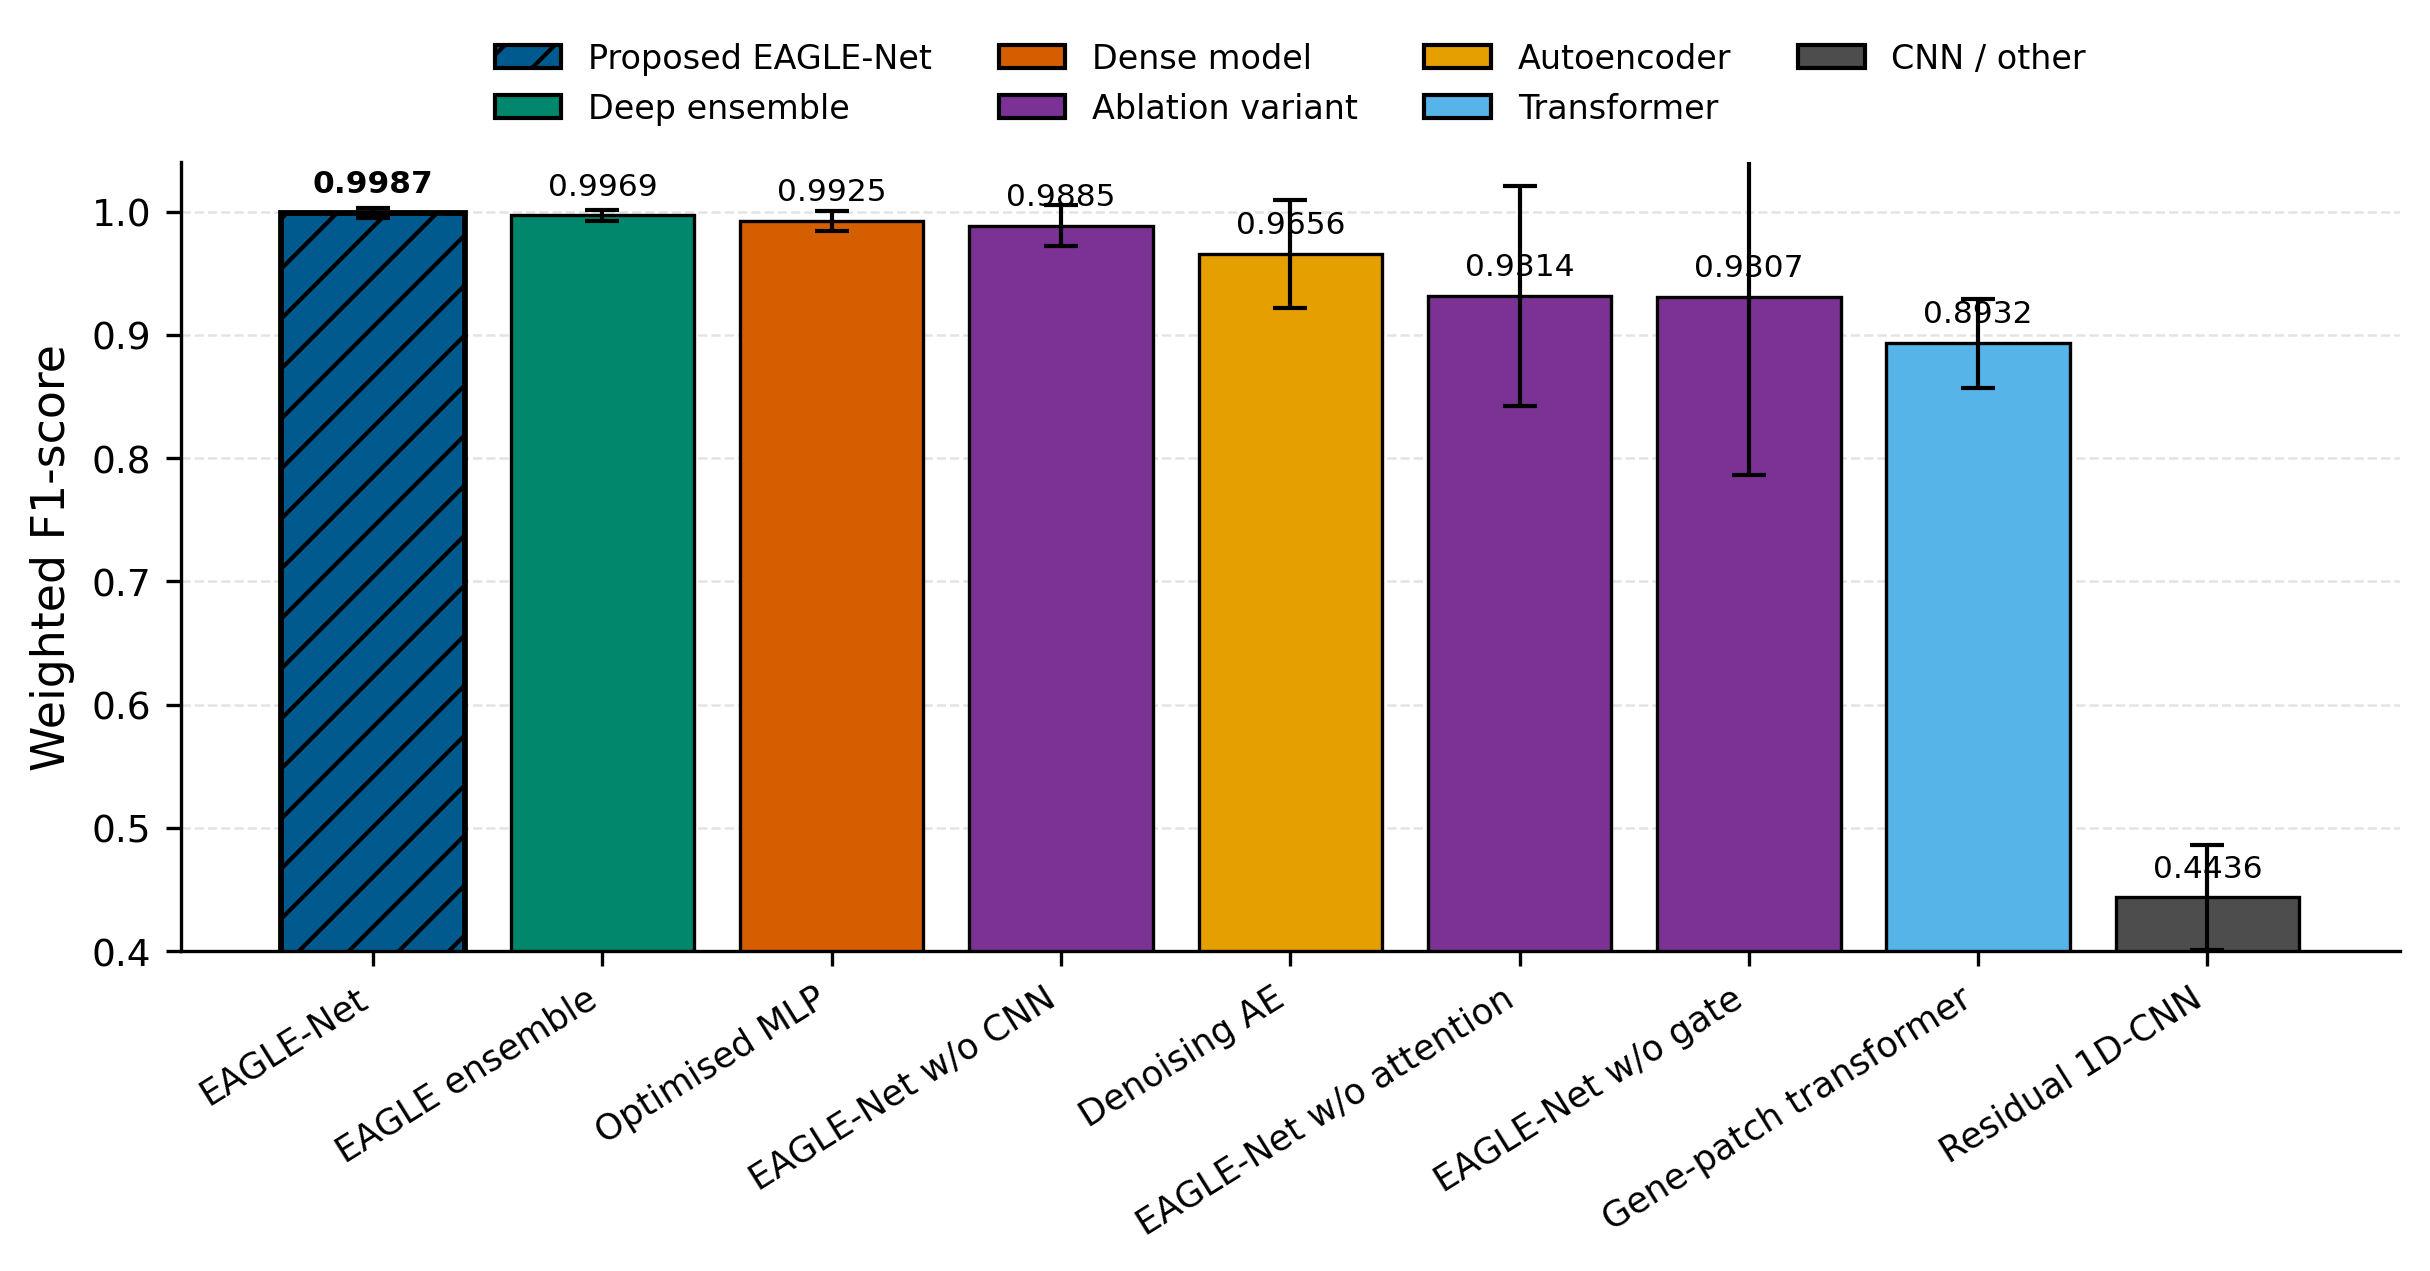

In [15]:
# ============================================================
# Fig 2. Comparative weighted F1-score of EAGLE-Net and
# deep learning comparator models
#
# Bars = mean weighted F1-score
# Error bars = standard deviation
# Colourful publication-style version
# Requires: main_table
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Prepare data
# -----------------------------

df = main_table.copy()

name_map = {
    "EAGLE-Net Proposed": "EAGLE-Net",
    "EAGLE Deep Ensemble": "EAGLE ensemble",
    "Optimised MLP": "Optimised MLP",
    "EAGLE-Net w/o CNN": "EAGLE-Net w/o CNN",
    "Denoising Autoencoder Classifier": "Denoising AE",
    "EAGLE-Net w/o Attention": "EAGLE-Net w/o attention",
    "EAGLE-Net w/o Gate": "EAGLE-Net w/o gate",
    "Gene-Patch Transformer": "Gene-patch transformer",
    "Residual 1D-CNN": "Residual 1D-CNN"
}

df["Display"] = df["Model"].map(name_map).fillna(df["Model"])

# Sort best to worst
df = df.sort_values("F1-score", ascending=False).reset_index(drop=True)

models = df["Display"].values
f1_mean = df["F1-score"].values
f1_sd = df["F1-score SD"].values

# -----------------------------
# Colour scheme
# -----------------------------
# Colourblind-friendly, publication-style palette

def model_colour(model):
    if model == "EAGLE-Net Proposed":
        return "#005A8D"   # deep blue
    elif model == "EAGLE Deep Ensemble":
        return "#00876C"   # green
    elif model == "Optimised MLP":
        return "#D55E00"   # vermillion/orange
    elif "w/o" in model:
        return "#7B3294"   # purple for ablation variants
    elif "Autoencoder" in model:
        return "#E69F00"   # amber
    elif "Transformer" in model:
        return "#56B4E9"   # sky blue
    elif "CNN" in model:
        return "#4D4D4D"   # dark grey
    else:
        return "#999999"

colors = [model_colour(m) for m in df["Model"]]

# -----------------------------
# Figure
# -----------------------------

fig, ax = plt.subplots(figsize=(8.2, 4.9), dpi=300)

x = np.arange(len(models))

bars = ax.bar(
    x,
    f1_mean,
    yerr=f1_sd,
    capsize=4,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    error_kw={
        "elinewidth": 1.0,
        "capthick": 1.0,
        "ecolor": "black"
    }
)

# Highlight proposed EAGLE-Net
for i, model in enumerate(df["Model"]):
    if model == "EAGLE-Net Proposed":
        bars[i].set_hatch("//")
        bars[i].set_linewidth(1.4)

# -----------------------------
# Formatting
# -----------------------------

ax.set_ylabel("Weighted F1-score", fontsize=11)
ax.set_ylim(0.40, 1.04)

ax.set_xticks(x)
ax.set_xticklabels(
    models,
    rotation=32,
    ha="right",
    fontsize=8.5
)

ax.tick_params(axis="y", labelsize=9)

# Light horizontal grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

ax.set_axisbelow(True)

# Remove top/right border
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Value labels
for i, value in enumerate(f1_mean):
    ax.text(
        i,
        value + 0.012,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=7.5,
        fontweight="bold" if df.loc[i, "Model"] == "EAGLE-Net Proposed" else "normal"
    )

# -----------------------------
# Legend
# -----------------------------

legend_elements = [
    Patch(facecolor="#005A8D", edgecolor="black", hatch="//", label="Proposed EAGLE-Net"),
    Patch(facecolor="#00876C", edgecolor="black", label="Deep ensemble"),
    Patch(facecolor="#D55E00", edgecolor="black", label="Dense model"),
    Patch(facecolor="#7B3294", edgecolor="black", label="Ablation variant"),
    Patch(facecolor="#E69F00", edgecolor="black", label="Autoencoder"),
    Patch(facecolor="#56B4E9", edgecolor="black", label="Transformer"),
    Patch(facecolor="#4D4D4D", edgecolor="black", label="CNN / other")
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.19),
    ncol=4,
    frameon=False,
    fontsize=8
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

# -----------------------------
# Save
# -----------------------------

plt.savefig(
    "Fig2_Comparative_Weighted_F1_EAGLE_Net_colour.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Fig2_Comparative_Weighted_F1_EAGLE_Net_colour.pdf",
    bbox_inches="tight"
)

plt.show()

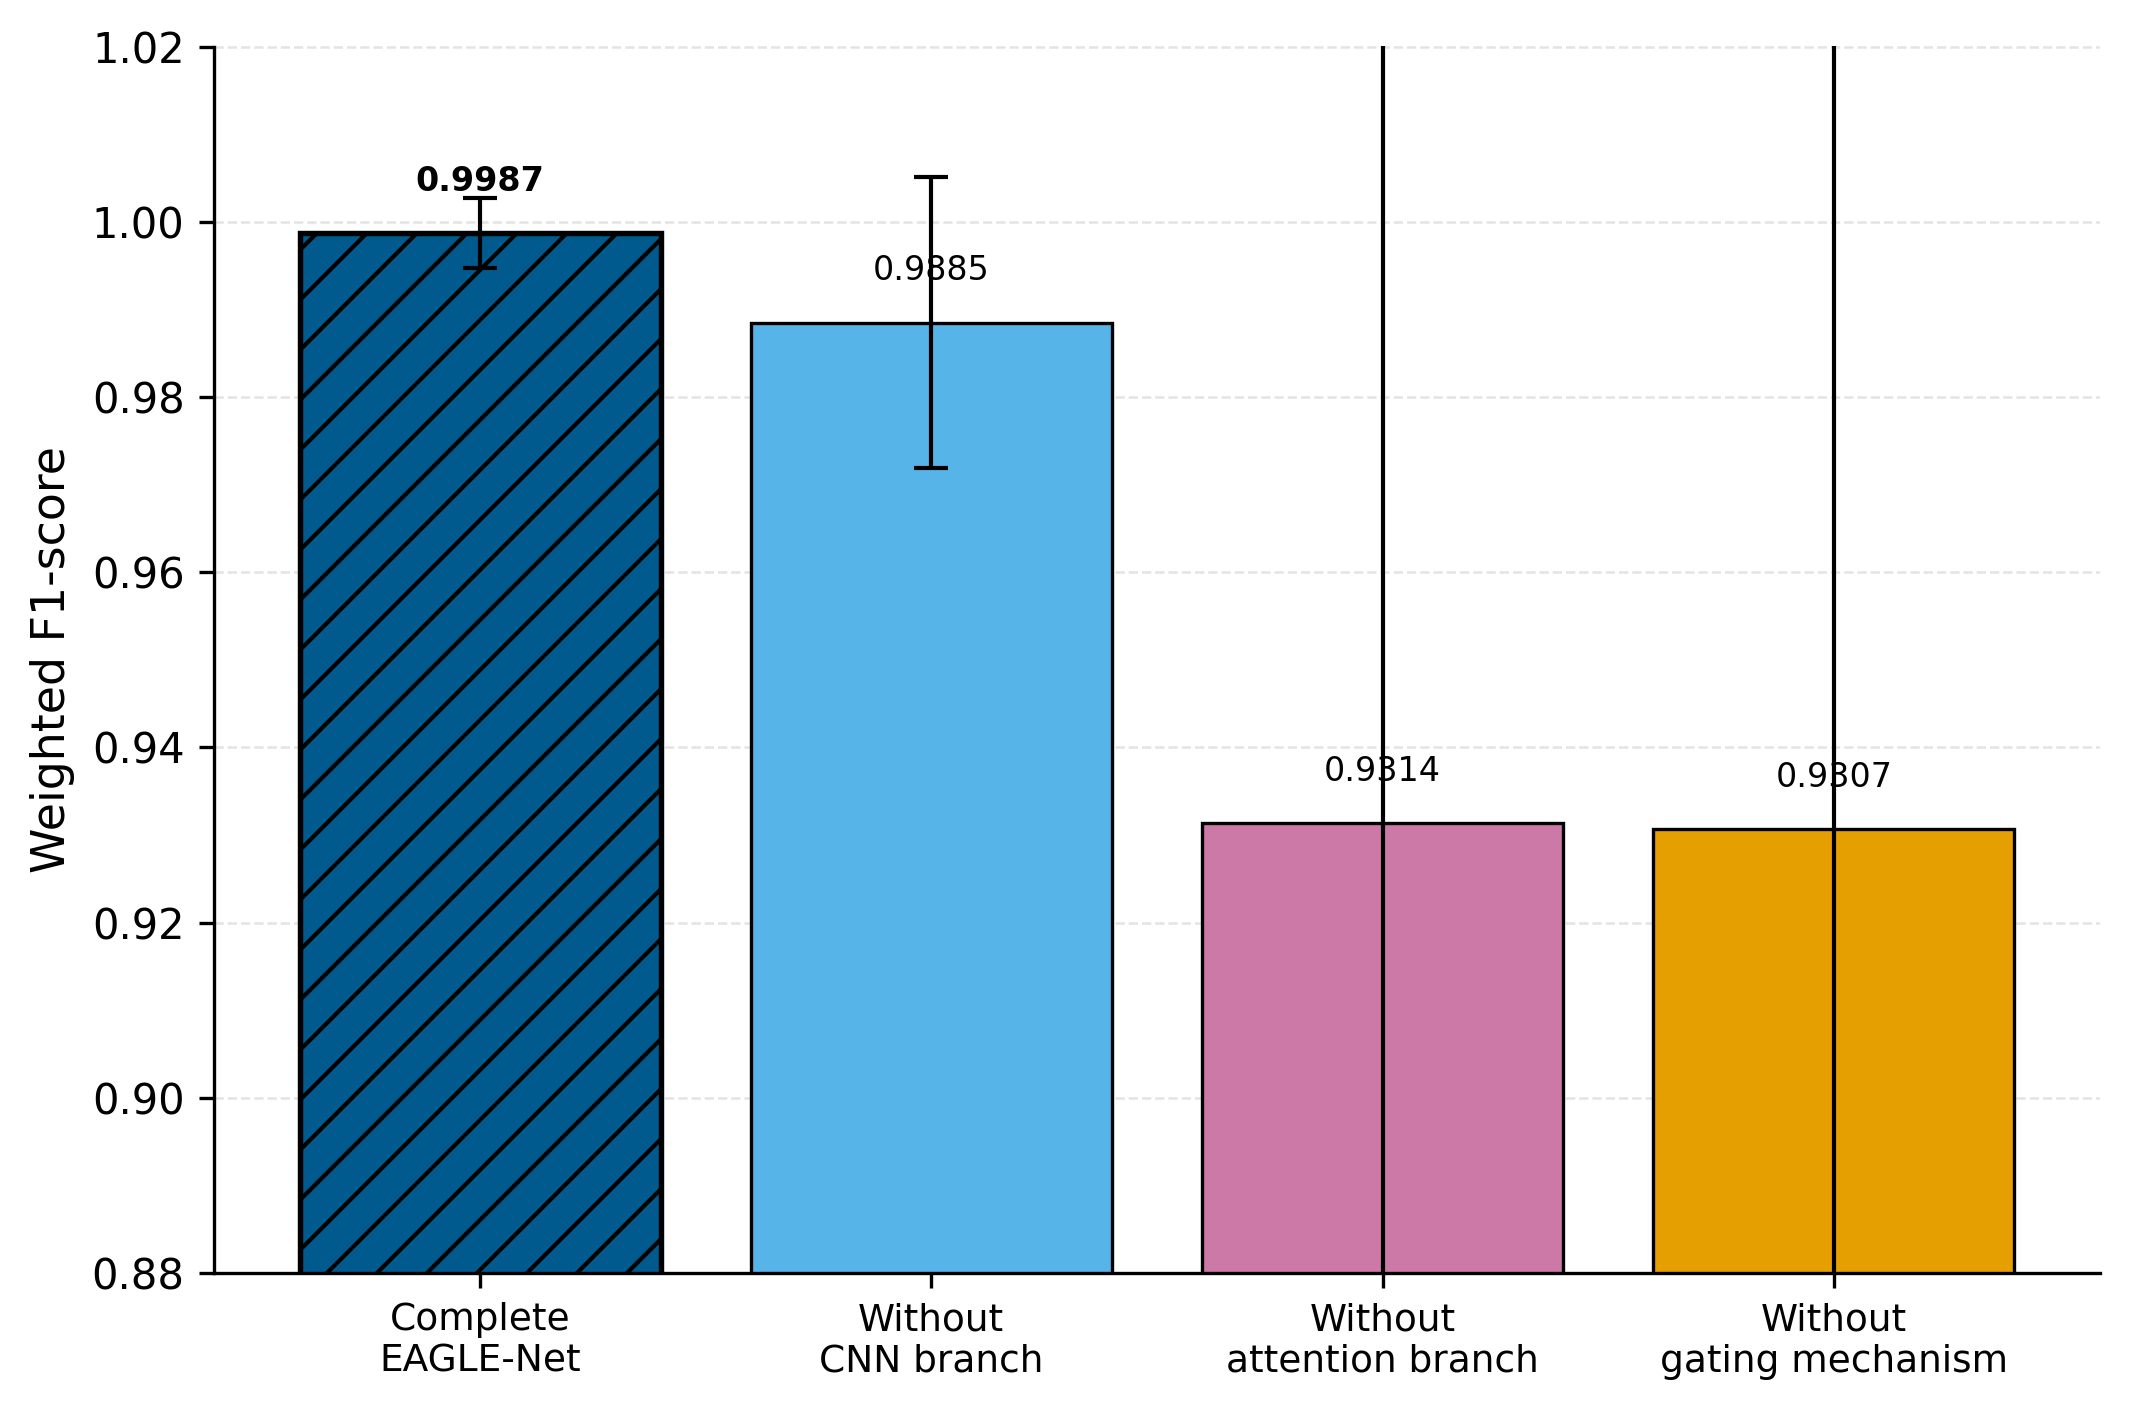

In [16]:
# ============================================================
# Fig 3. Ablation analysis of EAGLE-Net components
# Bars = mean weighted F1-score
# Error bars = standard deviation
# Requires: ablation_table OR main_table
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Prepare data
# -----------------------------

if "ablation_table" in globals():
    df = ablation_table.copy()
else:
    df = main_table.copy()
    ablation_models = [
        "EAGLE-Net Proposed",
        "EAGLE-Net w/o CNN",
        "EAGLE-Net w/o Attention",
        "EAGLE-Net w/o Gate"
    ]
    df = df[df["Model"].isin(ablation_models)].copy()

name_map = {
    "EAGLE-Net Proposed": "Complete\nEAGLE-Net",
    "EAGLE-Net w/o CNN": "Without\nCNN branch",
    "EAGLE-Net w/o Attention": "Without\nattention branch",
    "EAGLE-Net w/o Gate": "Without\ngating mechanism"
}

df["Display"] = df["Model"].map(name_map).fillna(df["Model"])

# Keep intended order
order = [
    "EAGLE-Net Proposed",
    "EAGLE-Net w/o CNN",
    "EAGLE-Net w/o Attention",
    "EAGLE-Net w/o Gate"
]
df["Model"] = pd.Categorical(df["Model"], categories=order, ordered=True)
df = df.sort_values("Model").reset_index(drop=True)

models = df["Display"].values
f1_mean = df["F1-score"].values
f1_sd = df["F1-score SD"].values

# -----------------------------
# Colours
# -----------------------------

colors = [
    "#005A8D",   # Complete EAGLE-Net
    "#56B4E9",   # w/o CNN
    "#CC79A7",   # w/o Attention
    "#E69F00"    # w/o Gate
]

# -----------------------------
# Figure
# -----------------------------

fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=300)

x = np.arange(len(models))

bars = ax.bar(
    x,
    f1_mean,
    yerr=f1_sd,
    capsize=4,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    error_kw={
        "elinewidth": 1.0,
        "capthick": 1.0,
        "ecolor": "black"
    }
)

# Highlight complete model
bars[0].set_hatch("//")
bars[0].set_linewidth(1.3)

# -----------------------------
# Formatting
# -----------------------------

ax.set_ylabel("Weighted F1-score", fontsize=11)
ax.set_ylim(0.88, 1.02)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)

ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Value labels
for i, value in enumerate(f1_mean):
    ax.text(
        i,
        value + 0.004,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold" if i == 0 else "normal"
    )

plt.tight_layout()

# -----------------------------
# Save
# -----------------------------

plt.savefig("Fig3_Ablation_EAGLE_Net.png", dpi=600, bbox_inches="tight")
plt.savefig("Fig3_Ablation_EAGLE_Net.pdf", bbox_inches="tight")

plt.show()

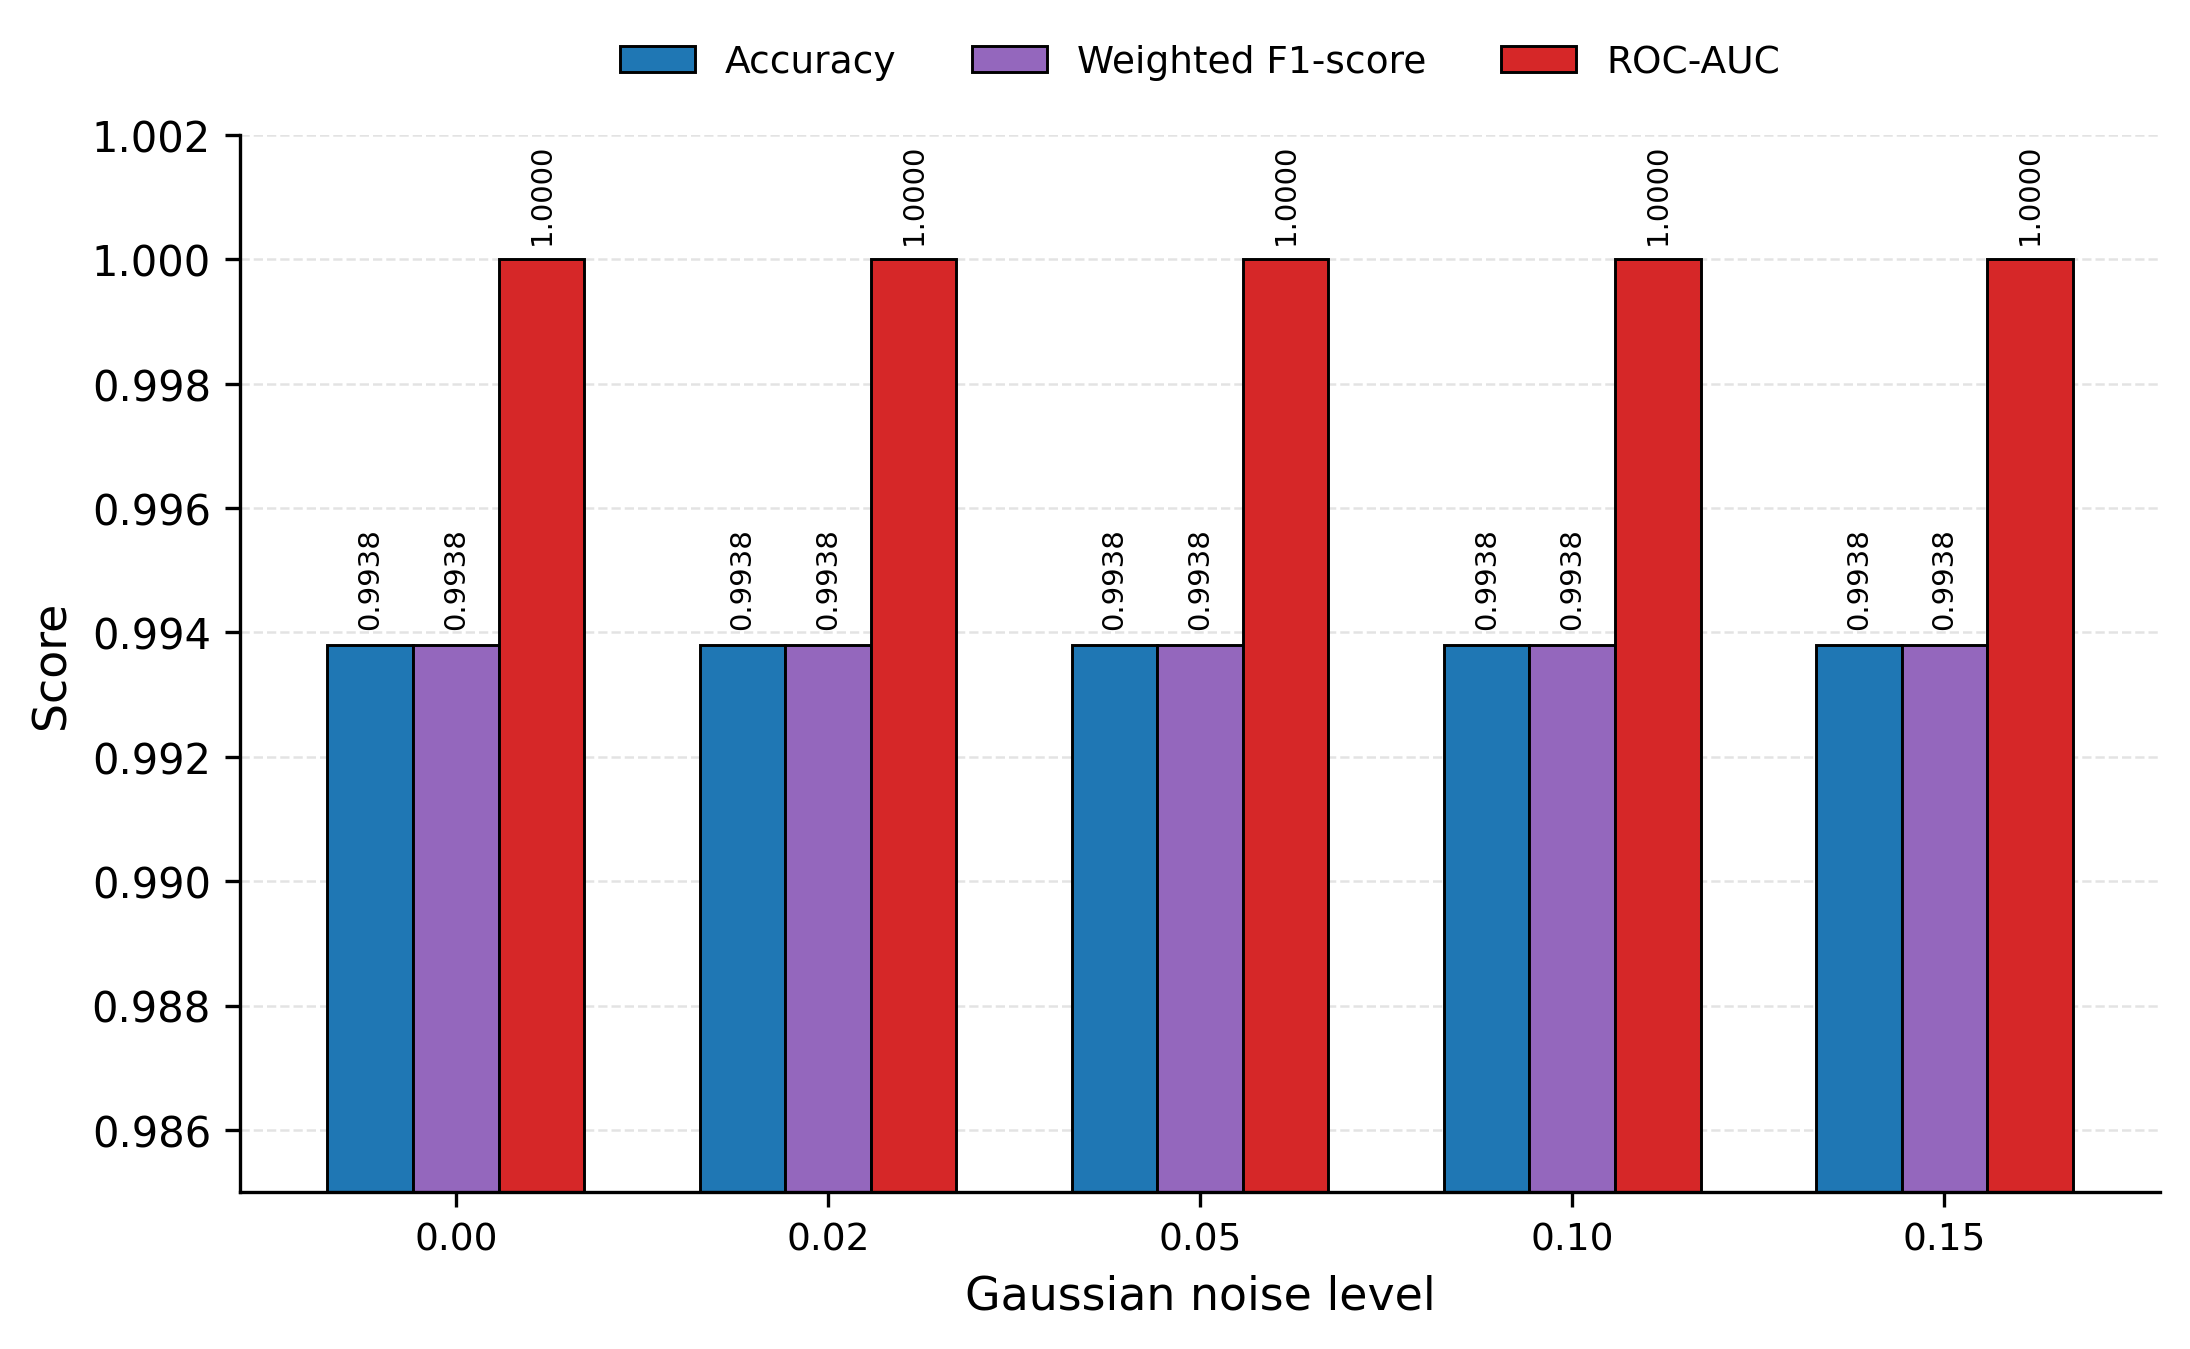

In [21]:
# ============================================================
# Fig 4. Robustness analysis under Gaussian noise perturbation
# Grouped bar chart: Accuracy, weighted F1-score, ROC-AUC
# across noise levels
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Prepare data
# -----------------------------

if "robust_table" in globals():
    df = robust_table.copy()
elif "robustness_table" in globals():
    df = robustness_table.copy()
else:
    df = pd.DataFrame({
        "Noise Level": [0.00, 0.02, 0.05, 0.10, 0.15],
        "Accuracy": [0.9938, 0.9938, 0.9938, 0.9938, 0.9938],
        "F1-score": [0.9938, 0.9938, 0.9938, 0.9938, 0.9938],
        "ROC-AUC": [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]
    })

df = df.rename(columns={
    "Noise_Level": "Noise Level",
    "F1_score": "F1-score",
    "ROC_AUC": "ROC-AUC"
})

df = df[["Noise Level", "Accuracy", "F1-score", "ROC-AUC"]].copy()
df = df.sort_values("Noise Level").reset_index(drop=True)

# -----------------------------
# Plot data
# -----------------------------

noise = df["Noise Level"].values
metrics = ["Accuracy", "F1-score", "ROC-AUC"]

x = np.arange(len(noise))
width = 0.23

colors = {
    "Accuracy": "#1f77b4",
    "F1-score": "#9467bd",
    "ROC-AUC": "#d62728"
}

# -----------------------------
# Figure
# -----------------------------

fig, ax = plt.subplots(figsize=(7.4, 4.6), dpi=300)

for i, metric in enumerate(metrics):
    ax.bar(
        x + (i - 1) * width,
        df[metric].values,
        width=width,
        color=colors[metric],
        edgecolor="black",
        linewidth=0.7,
        label="Weighted F1-score" if metric == "F1-score" else metric
    )

# -----------------------------
# Formatting
# -----------------------------

ax.set_xlabel("Gaussian noise level", fontsize=11)
ax.set_ylabel("Score", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels([f"{v:.2f}" for v in noise], fontsize=9)

ax.set_ylim(0.985, 1.002)

ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
    fontsize=9
)

# Value labels only once per metric group, small and clean
for i, metric in enumerate(metrics):
    for j, value in enumerate(df[metric].values):
        ax.text(
            j + (i - 1) * width,
            value + 0.00025,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

plt.tight_layout()

# -----------------------------
# Save
# -----------------------------

plt.savefig("Fig4_Robustness_Gaussian_Noise_Bar.png", dpi=600, bbox_inches="tight")
plt.savefig("Fig4_Robustness_Gaussian_Noise_Bar.pdf", bbox_inches="tight")

plt.show()

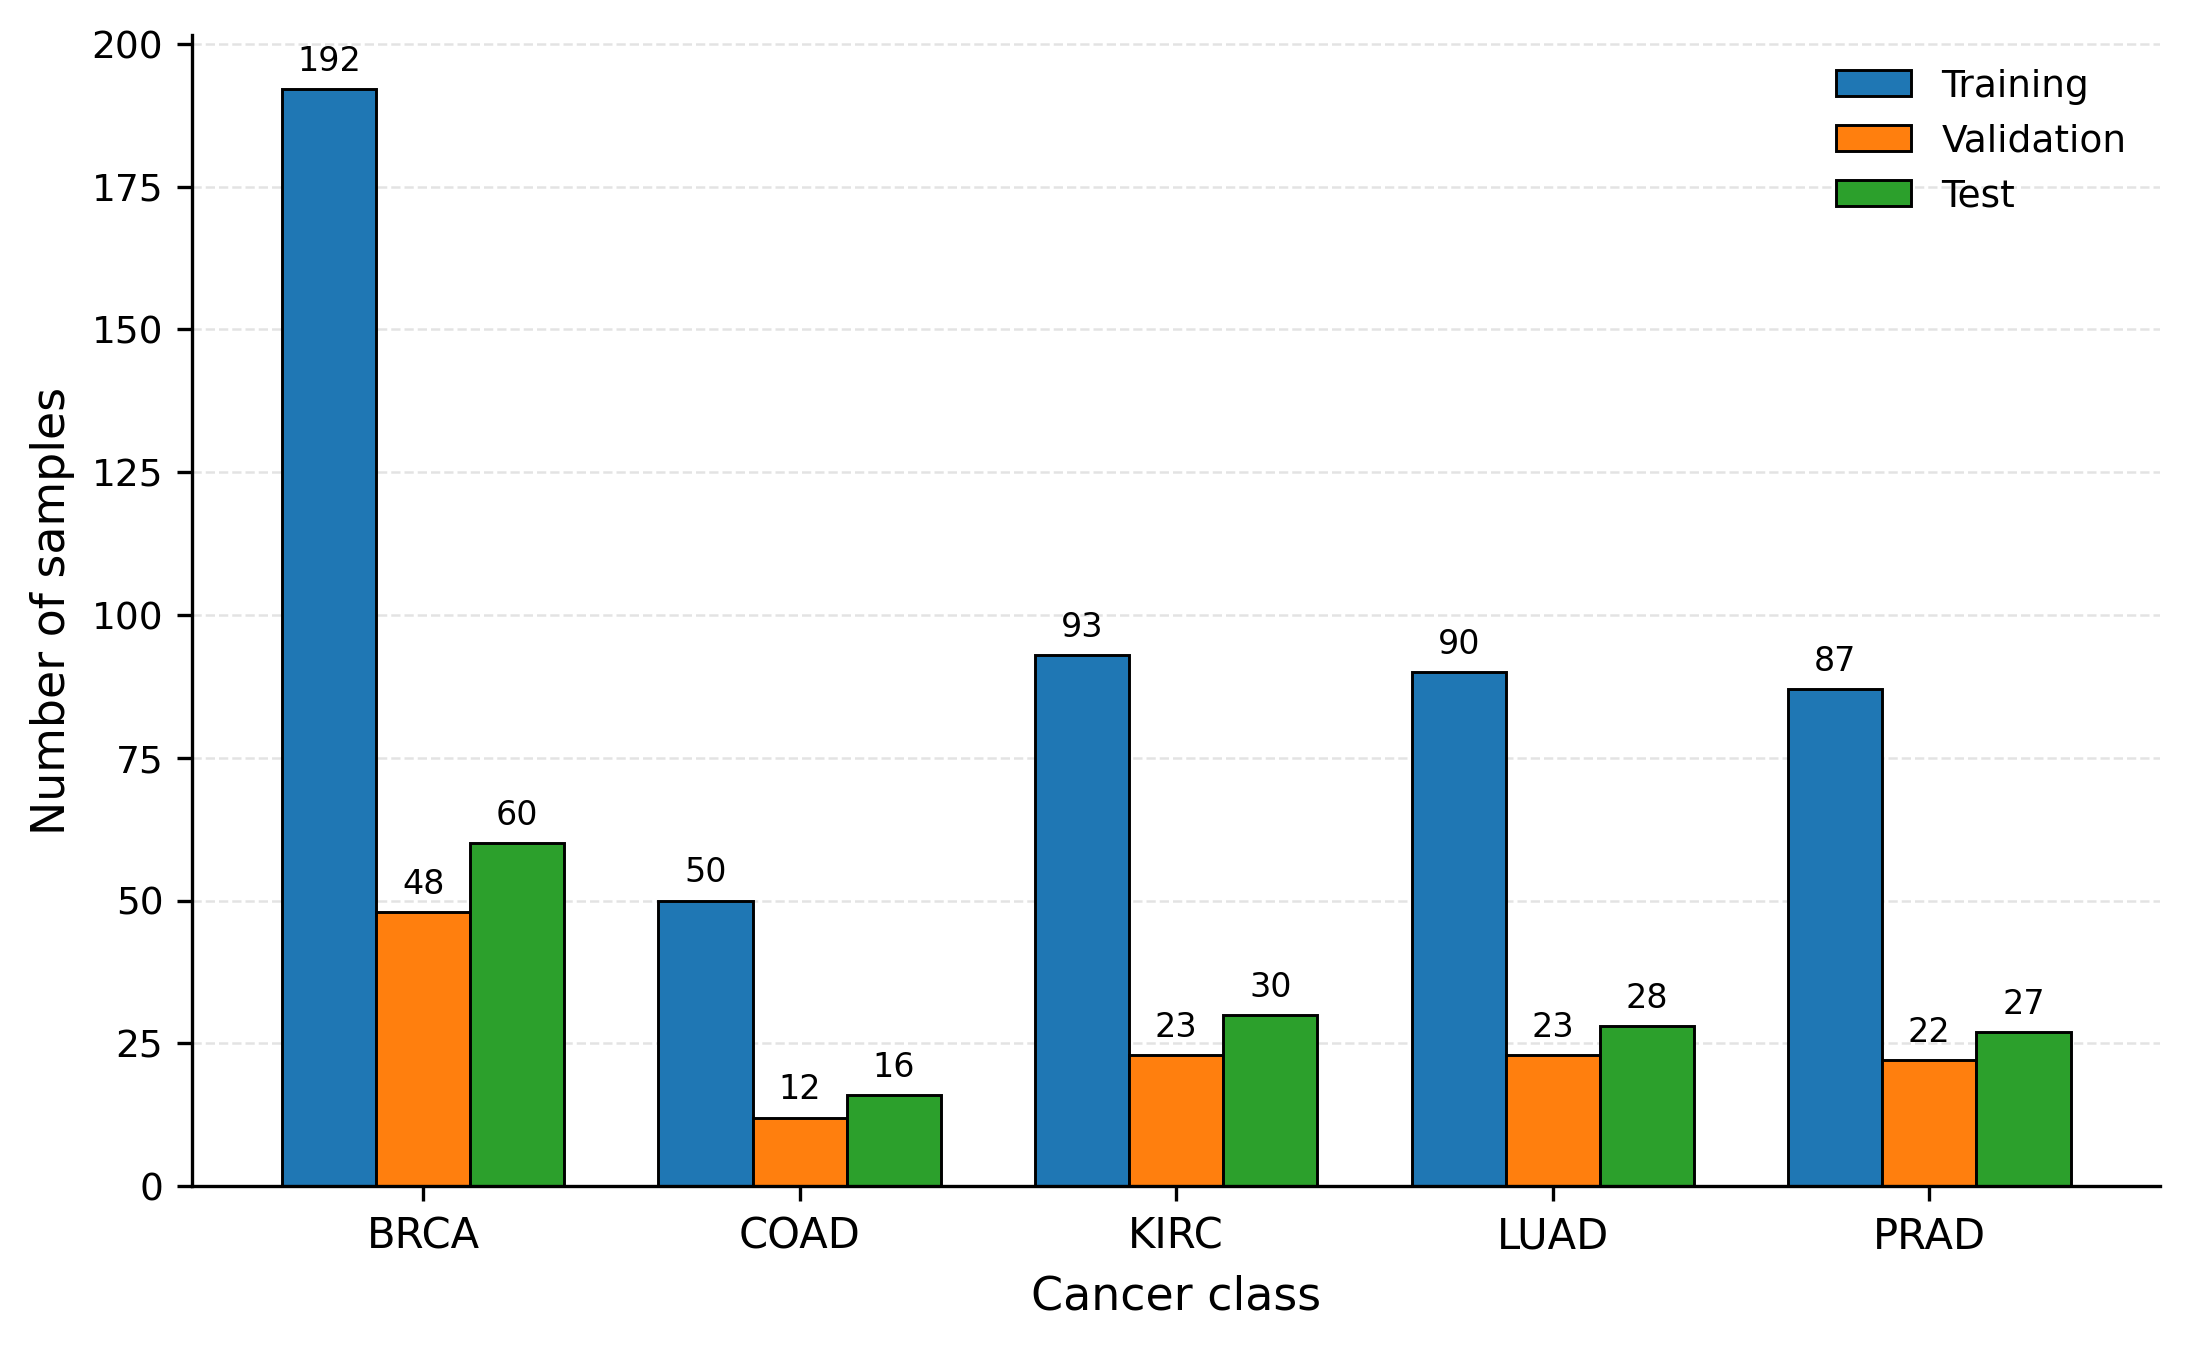

,Class,Training,Validation,Test
0,BRCA,192,48,60
1,COAD,50,12,16
2,KIRC,93,23,30
3,LUAD,90,23,28
4,PRAD,87,22,27


In [22]:
# ============================================================
# Train / Validation / Test class distribution plot
# Paper-ready grouped bar chart
# Requires: y_train, y_val, y_test, class_names
# If unavailable, recreate from your known split counts manually
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Option A: use existing variables from your notebook
# ------------------------------------------------------------

if all(v in globals() for v in ["y_train", "y_val", "y_test", "class_names"]):

    train_counts = pd.Series(y_train).value_counts().sort_index()
    val_counts   = pd.Series(y_val).value_counts().sort_index()
    test_counts  = pd.Series(y_test).value_counts().sort_index()

    split_df = pd.DataFrame({
        "Class": class_names,
        "Training": [train_counts.get(i, 0) for i in range(len(class_names))],
        "Validation": [val_counts.get(i, 0) for i in range(len(class_names))],
        "Test": [test_counts.get(i, 0) for i in range(len(class_names))]
    })

else:
    # --------------------------------------------------------
    # Option B: fallback using your known total class counts
    # Approximate stratified 64/16/20 split from 801 samples
    # Replace these if your exact notebook counts differ.
    # --------------------------------------------------------

    split_df = pd.DataFrame({
        "Class": ["BRCA", "COAD", "KIRC", "LUAD", "PRAD"],
        "Training":   [192, 50, 93, 90, 87],
        "Validation": [48, 12, 23, 23, 22],
        "Test":       [60, 16, 30, 28, 27]
    })

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

classes = split_df["Class"].values
x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(7.4, 4.6), dpi=300)

bars1 = ax.bar(
    x - width,
    split_df["Training"],
    width,
    label="Training",
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.7
)

bars2 = ax.bar(
    x,
    split_df["Validation"],
    width,
    label="Validation",
    color="#ff7f0e",
    edgecolor="black",
    linewidth=0.7
)

bars3 = ax.bar(
    x + width,
    split_df["Test"],
    width,
    label="Test",
    color="#2ca02c",
    edgecolor="black",
    linewidth=0.7
)

# ------------------------------------------------------------
# Value labels
# ------------------------------------------------------------

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 2,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=8
        )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_xlabel("Cancer class", fontsize=11)
ax.set_ylabel("Number of samples", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=10)

ax.tick_params(axis="y", labelsize=9)

ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=9
)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.savefig("Fig_Split_Class_Distribution.png", dpi=600, bbox_inches="tight")
plt.savefig("Fig_Split_Class_Distribution.pdf", bbox_inches="tight")

plt.show()

display(split_df)

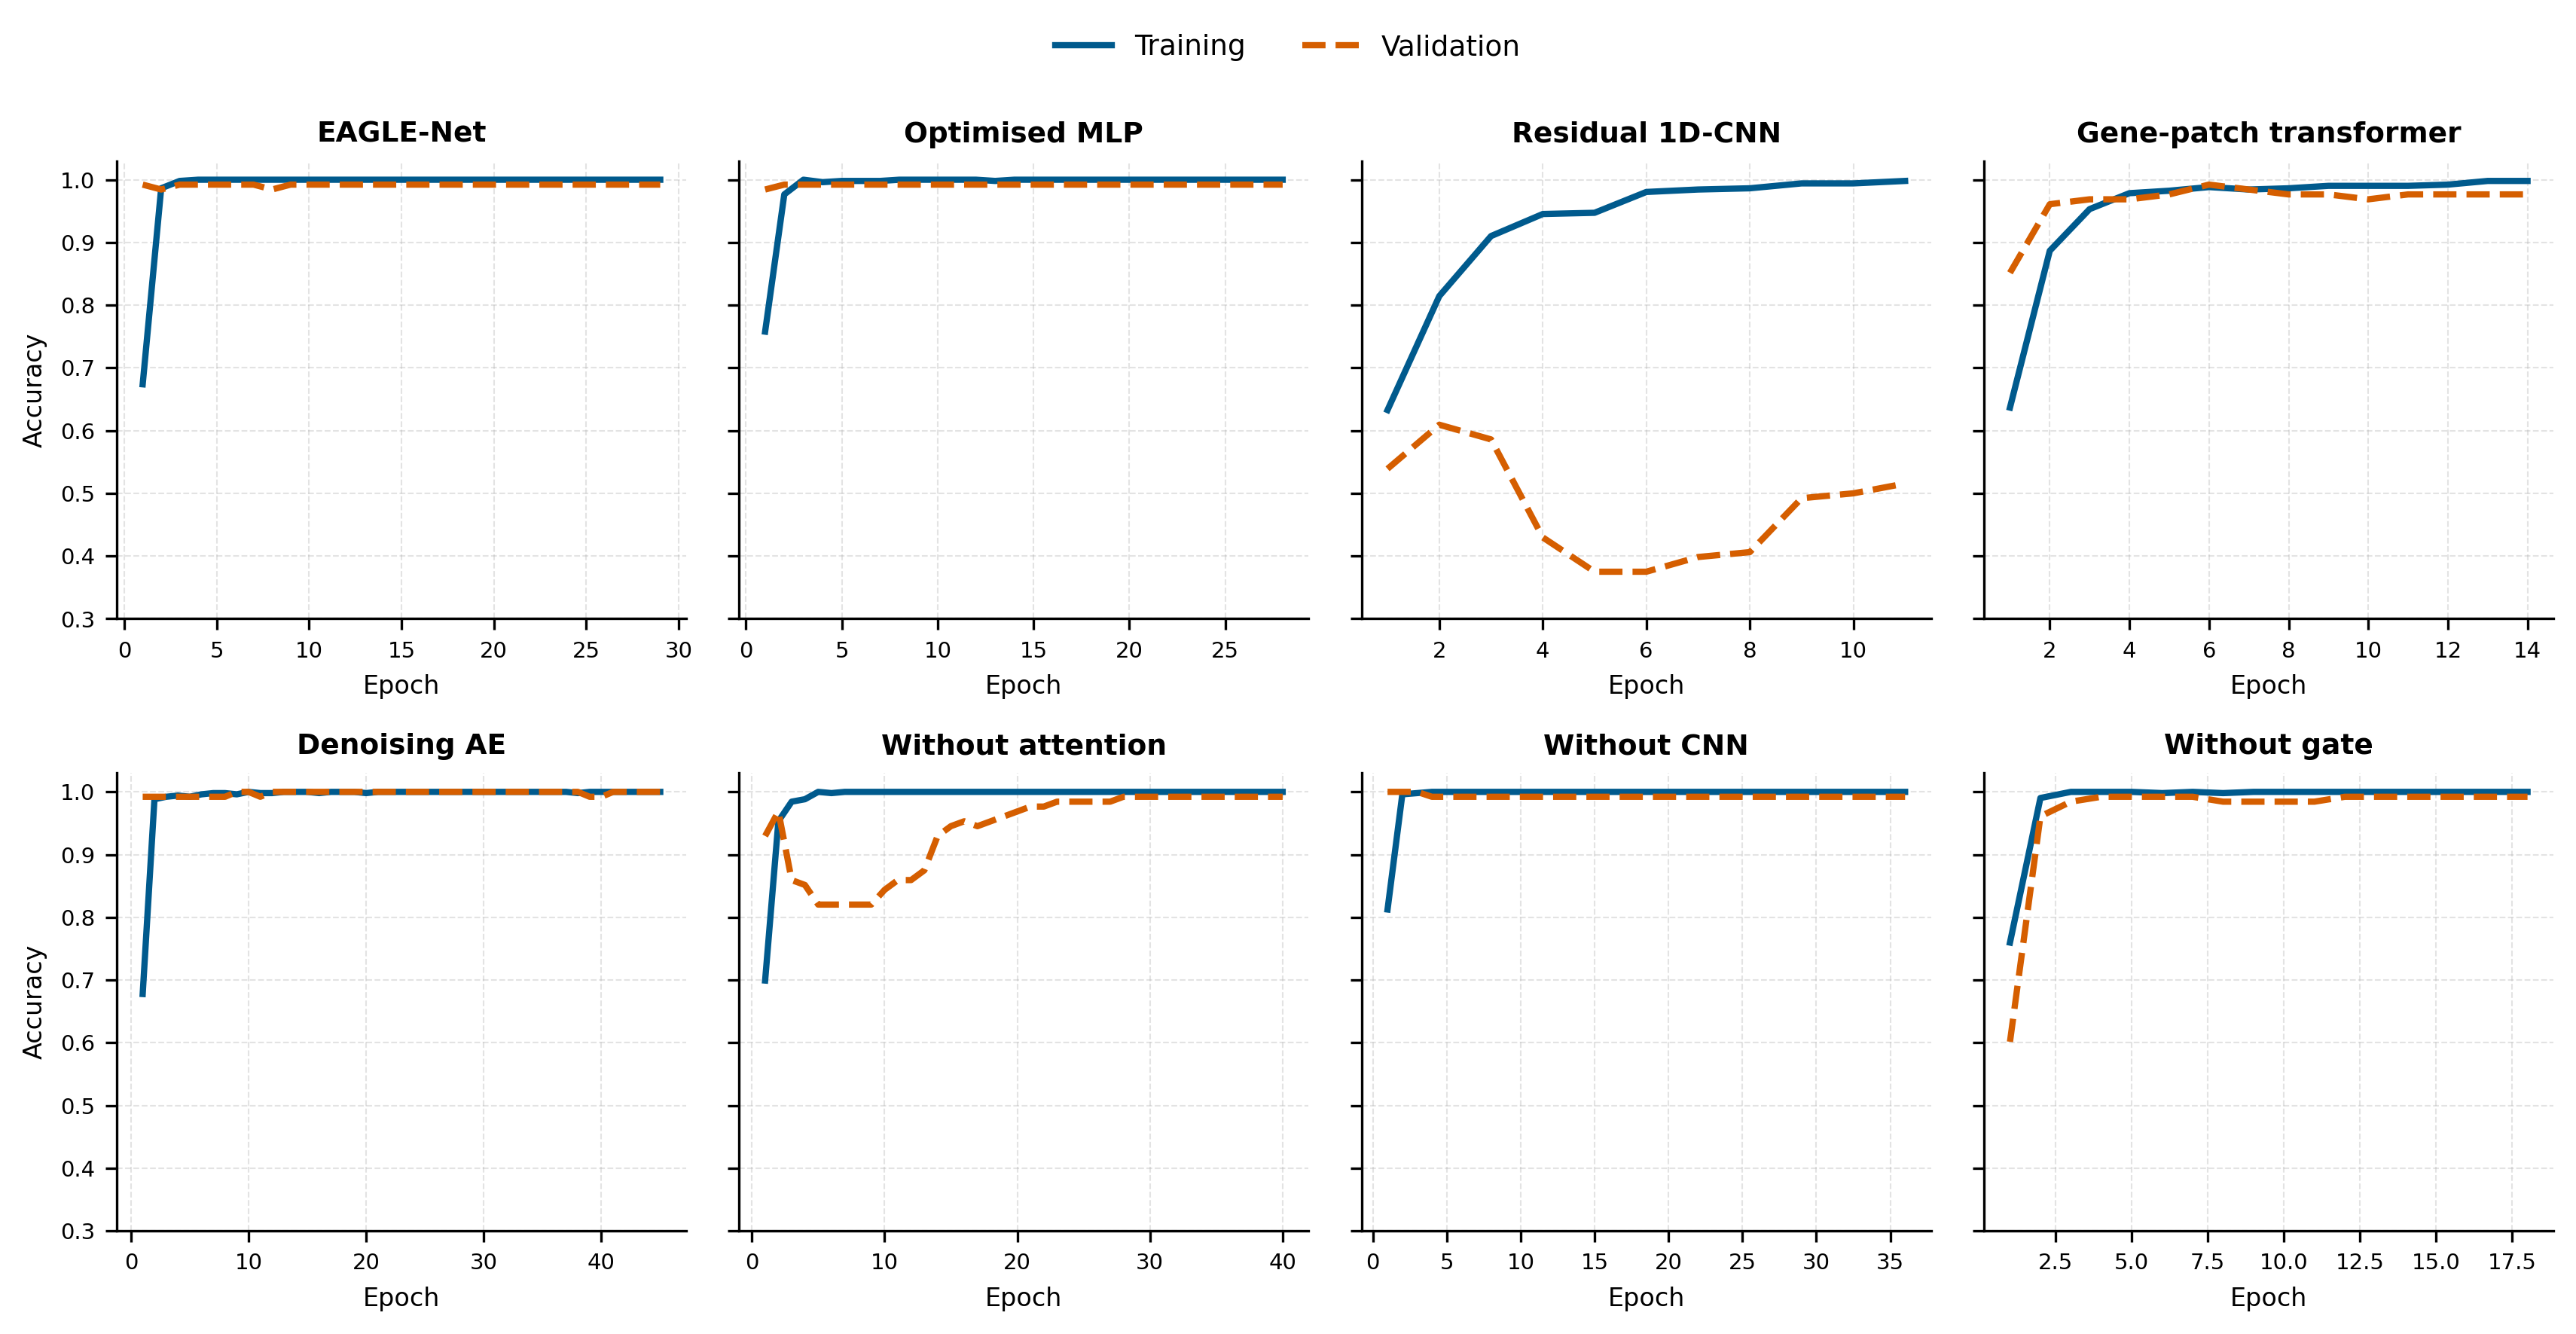

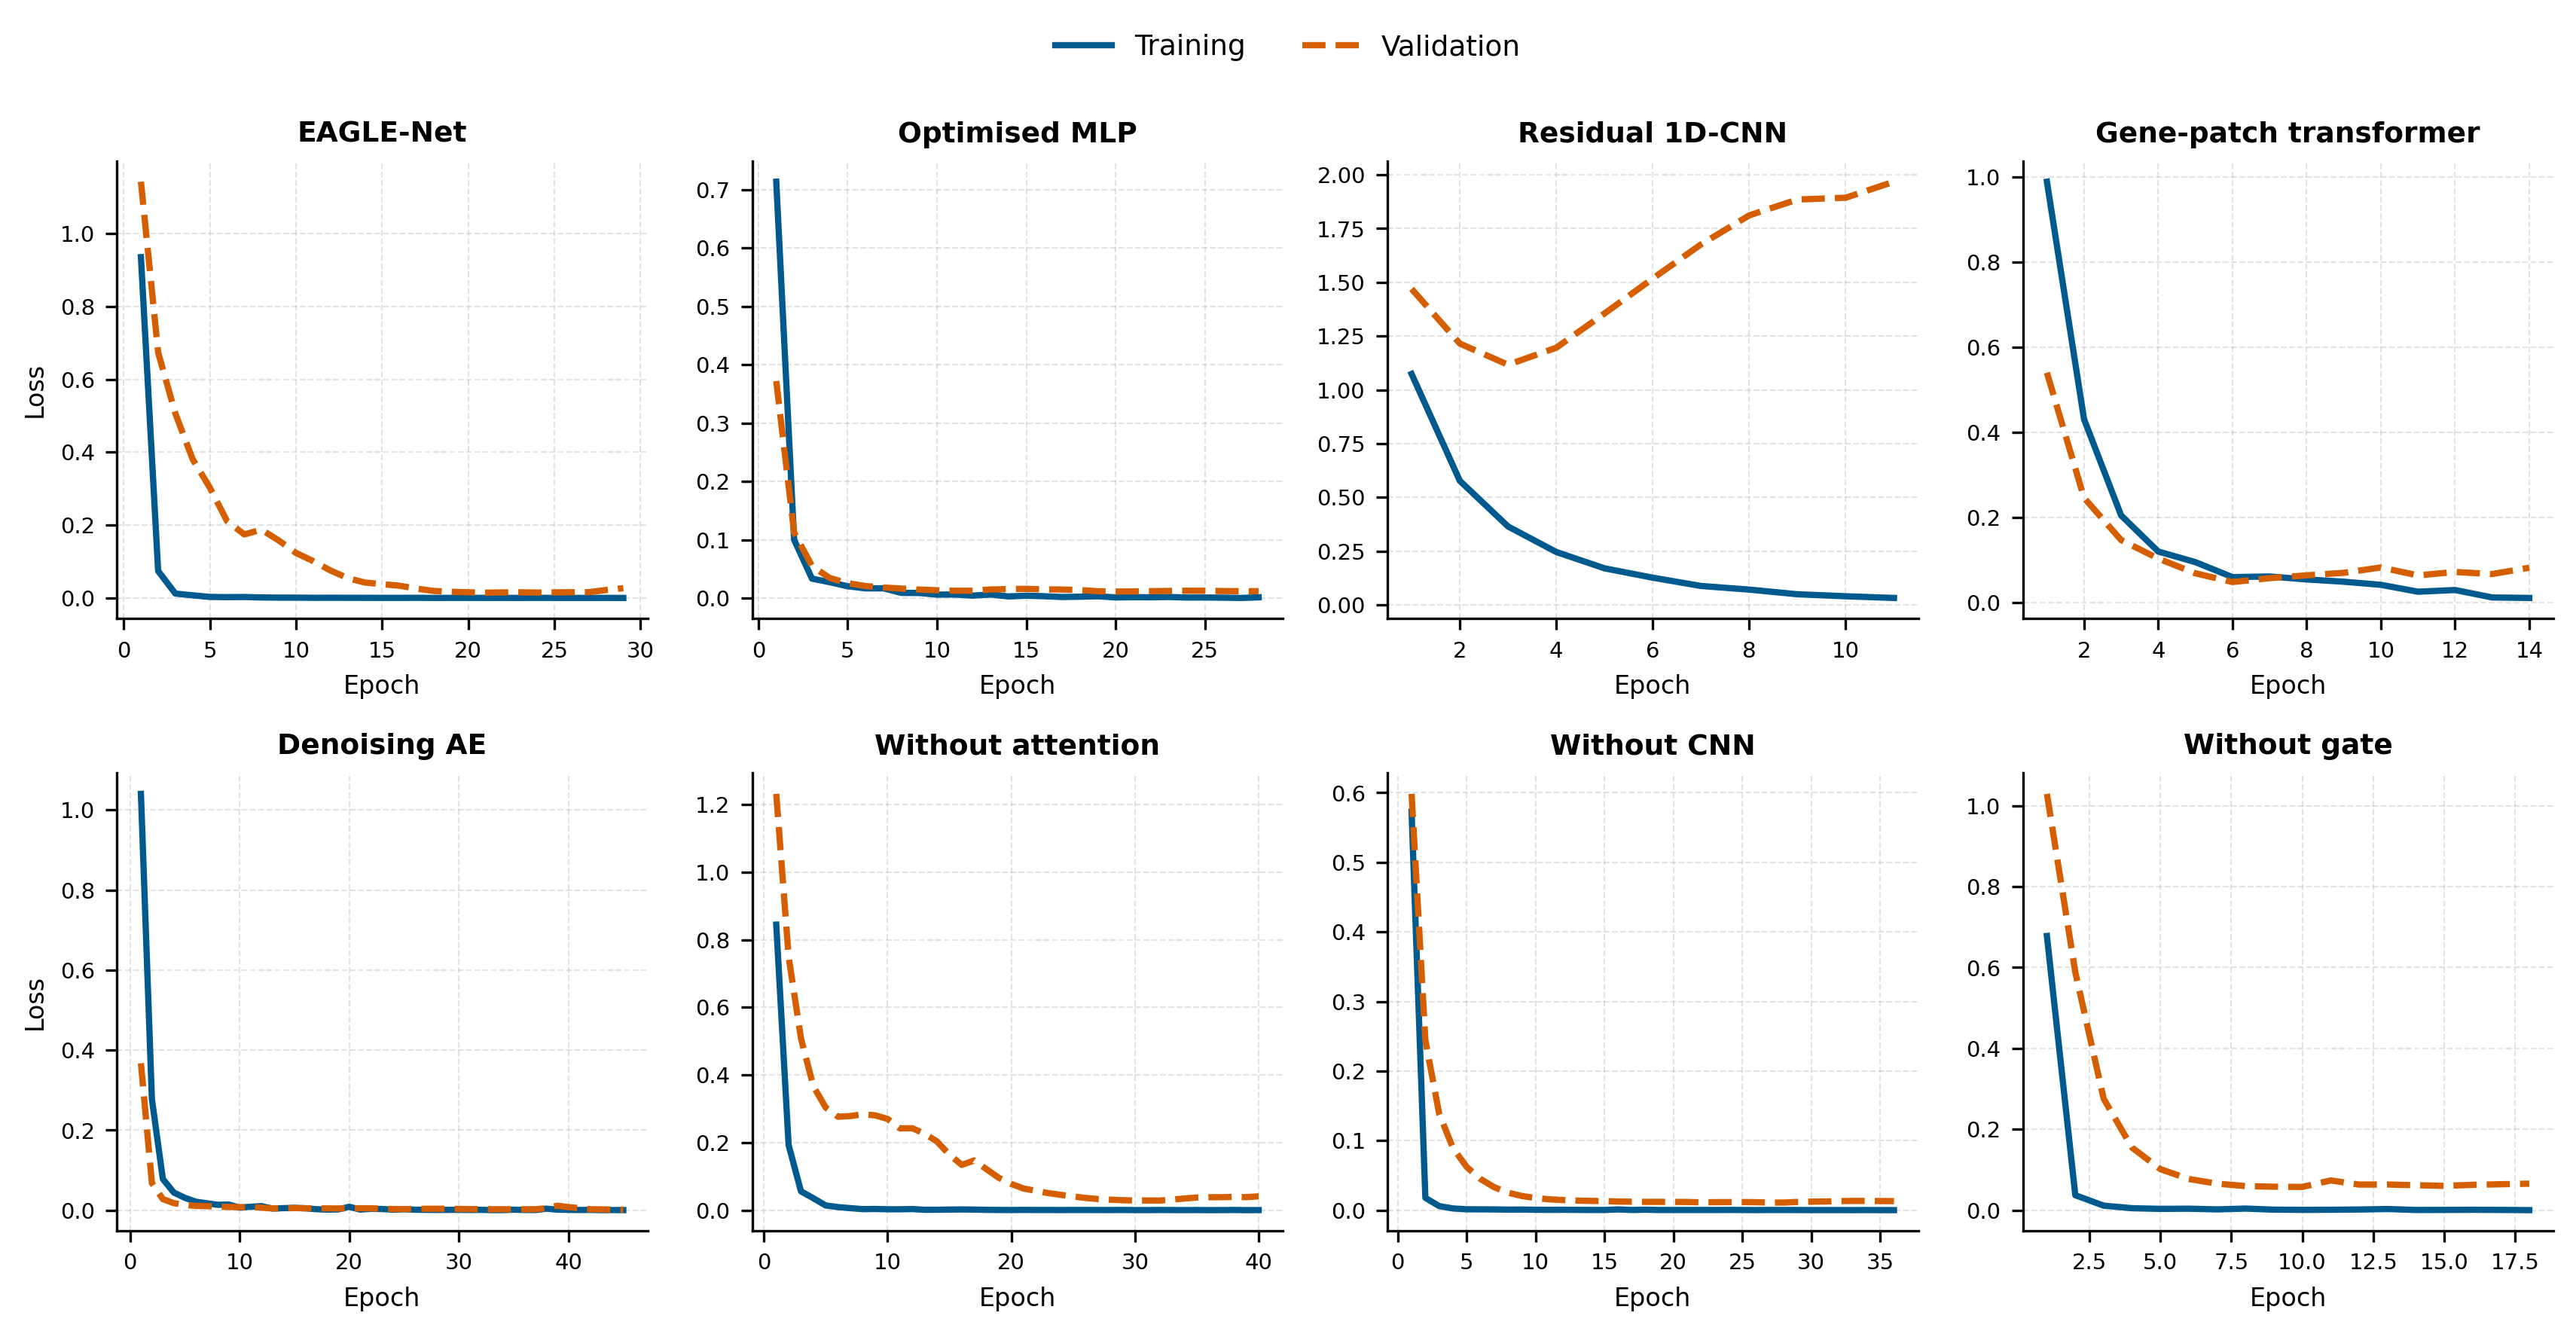

In [6]:
# ============================================================
# CLEAN SMALL-MULTIPLE TRAINING / VALIDATION CURVES
# One panel per model
# Left output: Accuracy curves
# Right output: Loss curves
# Requires: curve_histories
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import math

# ------------------------------------------------------------
# Display names
# ------------------------------------------------------------

display_names = {
    "EAGLE-Net": "EAGLE-Net",
    "Optimised MLP": "Optimised MLP",
    "Residual 1D-CNN": "Residual 1D-CNN",
    "Gene-patch transformer": "Gene-patch transformer",
    "Denoising AE classifier": "Denoising AE",
    "EAGLE-Net w/o attention": "Without attention",
    "EAGLE-Net w/o CNN": "Without CNN",
    "EAGLE-Net w/o gate": "Without gate"
}

model_order = [
    "EAGLE-Net",
    "Optimised MLP",
    "Residual 1D-CNN",
    "Gene-patch transformer",
    "Denoising AE classifier",
    "EAGLE-Net w/o attention",
    "EAGLE-Net w/o CNN",
    "EAGLE-Net w/o gate"
]

model_order = [m for m in model_order if m in curve_histories]

# ============================================================
# FIGURE A: ACCURACY CURVES
# ============================================================

n_models = len(model_order)
n_cols = 4
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(11.5, 5.8),
    dpi=300,
    sharey=True
)

axes = axes.flatten()

for idx, model_name in enumerate(model_order):
    ax = axes[idx]
    hist = curve_histories[model_name]

    epochs = np.arange(1, len(hist["accuracy"]) + 1)

    ax.plot(
        epochs,
        hist["accuracy"],
        color="#005A8D",
        linewidth=2.0,
        label="Training"
    )

    ax.plot(
        epochs,
        hist["val_accuracy"],
        color="#D55E00",
        linewidth=2.0,
        linestyle="--",
        label="Validation"
    )

    ax.set_title(
        display_names.get(model_name, model_name),
        fontsize=9,
        fontweight="bold"
    )

    ax.set_xlabel("Epoch", fontsize=8)
    ax.set_ylim(0.30, 1.03)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)

    ax.tick_params(axis="both", labelsize=7)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if idx % n_cols == 0:
        ax.set_ylabel("Accuracy", fontsize=8)

# Remove empty panels
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "Fig_Training_Validation_Accuracy_SmallMultiples.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Fig_Training_Validation_Accuracy_SmallMultiples.pdf",
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE B: LOSS CURVES
# ============================================================

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(11.5, 5.8),
    dpi=300,
    sharey=False
)

axes = axes.flatten()

for idx, model_name in enumerate(model_order):
    ax = axes[idx]
    hist = curve_histories[model_name]

    epochs = np.arange(1, len(hist["loss"]) + 1)

    ax.plot(
        epochs,
        hist["loss"],
        color="#005A8D",
        linewidth=2.0,
        label="Training"
    )

    ax.plot(
        epochs,
        hist["val_loss"],
        color="#D55E00",
        linewidth=2.0,
        linestyle="--",
        label="Validation"
    )

    ax.set_title(
        display_names.get(model_name, model_name),
        fontsize=9,
        fontweight="bold"
    )

    ax.set_xlabel("Epoch", fontsize=8)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)

    ax.tick_params(axis="both", labelsize=7)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if idx % n_cols == 0:
        ax.set_ylabel("Loss", fontsize=8)

# Remove empty panels
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "Fig_Training_Validation_Loss_SmallMultiples.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Fig_Training_Validation_Loss_SmallMultiples.pdf",
    bbox_inches="tight"
)

plt.show()

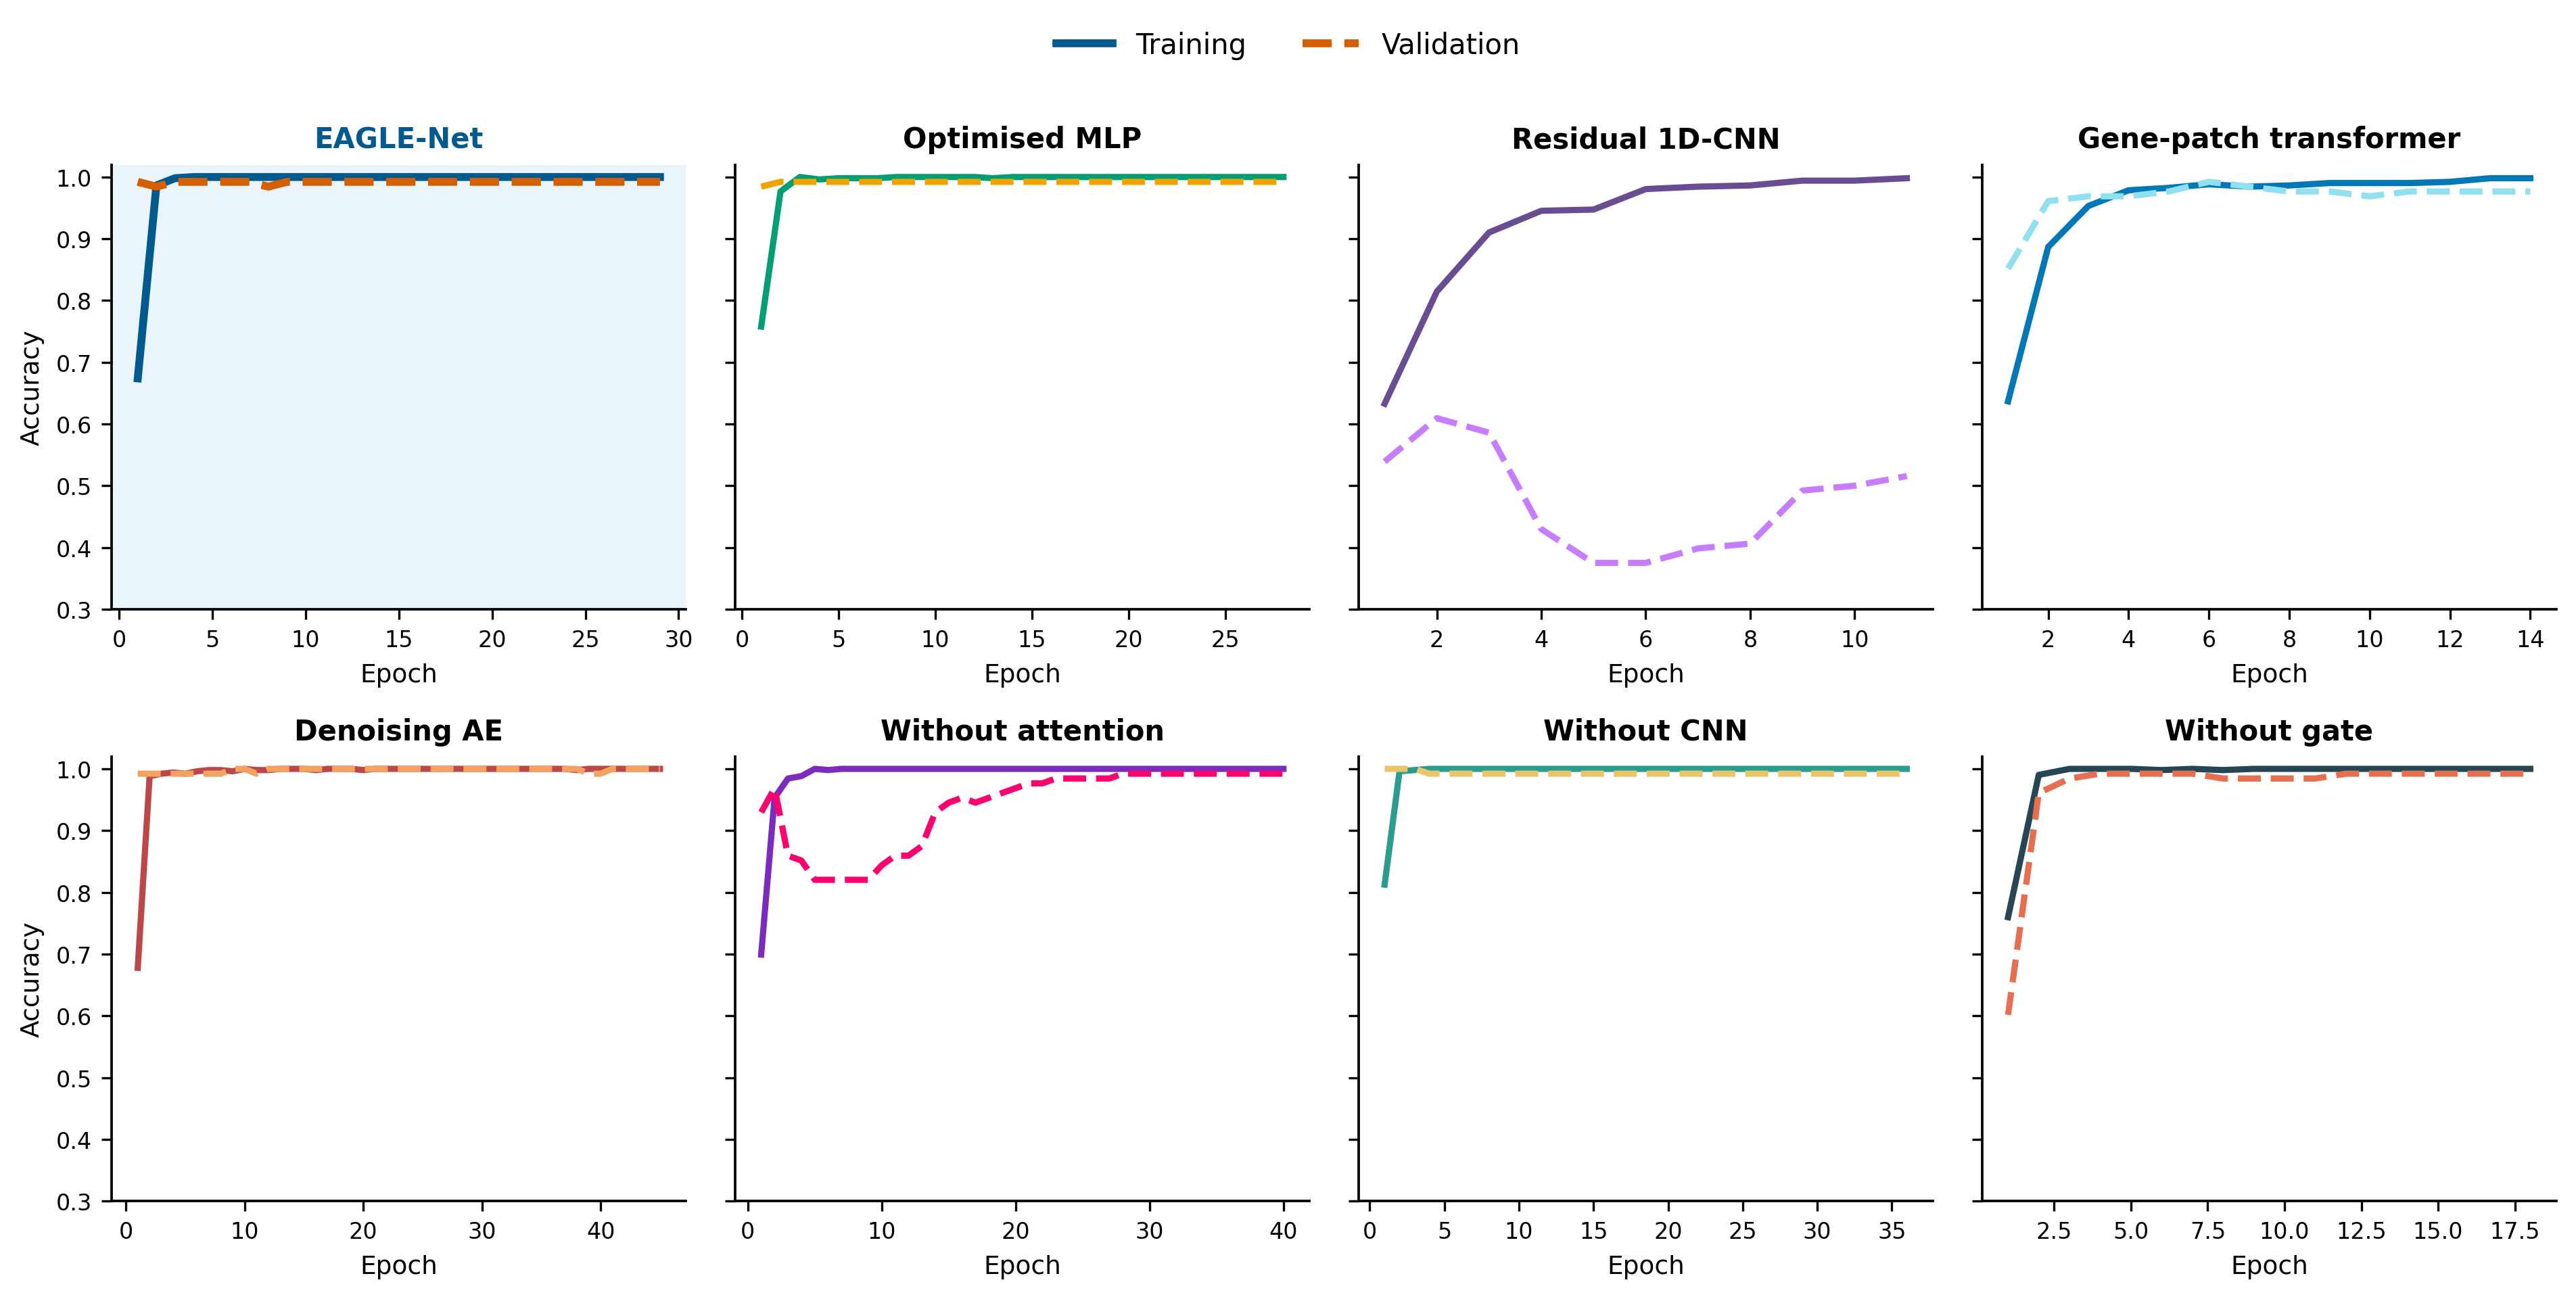

In [8]:
# ============================================================
# CLEAN + COLOURFUL TRAINING / VALIDATION ACCURACY CURVES
# Proposed EAGLE-Net highlighted
# No background grid
# Requires: curve_histories
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import math

display_names = {
    "EAGLE-Net": "EAGLE-Net",
    "Optimised MLP": "Optimised MLP",
    "Residual 1D-CNN": "Residual 1D-CNN",
    "Gene-patch transformer": "Gene-patch transformer",
    "Denoising AE classifier": "Denoising AE",
    "EAGLE-Net w/o attention": "Without attention",
    "EAGLE-Net w/o CNN": "Without CNN",
    "EAGLE-Net w/o gate": "Without gate"
}

model_order = [
    "EAGLE-Net",
    "Optimised MLP",
    "Residual 1D-CNN",
    "Gene-patch transformer",
    "Denoising AE classifier",
    "EAGLE-Net w/o attention",
    "EAGLE-Net w/o CNN",
    "EAGLE-Net w/o gate"
]

model_order = [m for m in model_order if m in curve_histories]

# Strong, readable palette
model_colours = {
    "EAGLE-Net": {
        "train": "#005A8D",   # deep blue
        "val":   "#D55E00",   # orange-red
        "face":  "#EAF4FB"
    },
    "Optimised MLP": {
        "train": "#009E73",   # green
        "val":   "#F0A202",   # amber
        "face":  "white"
    },
    "Residual 1D-CNN": {
        "train": "#6A4C93",   # purple
        "val":   "#C77DFF",   # lavender
        "face":  "white"
    },
    "Gene-patch transformer": {
        "train": "#0077B6",   # bright blue
        "val":   "#90E0EF",   # cyan
        "face":  "white"
    },
    "Denoising AE classifier": {
        "train": "#BC4749",   # red
        "val":   "#F4A261",   # peach
        "face":  "white"
    },
    "EAGLE-Net w/o attention": {
        "train": "#7B2CBF",   # violet
        "val":   "#FF006E",   # magenta
        "face":  "white"
    },
    "EAGLE-Net w/o CNN": {
        "train": "#2A9D8F",   # teal
        "val":   "#E9C46A",   # yellow
        "face":  "white"
    },
    "EAGLE-Net w/o gate": {
        "train": "#264653",   # dark teal
        "val":   "#E76F51",   # coral
        "face":  "white"
    }
}

n_models = len(model_order)
n_cols = 4
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12.8, 6.3),
    dpi=300,
    sharey=True
)

axes = np.array(axes).reshape(-1)

for idx, model_name in enumerate(model_order):
    ax = axes[idx]
    hist = curve_histories[model_name]

    train_acc = hist["accuracy"]
    val_acc = hist["val_accuracy"]
    epochs = np.arange(1, len(train_acc) + 1)

    colours = model_colours[model_name]
    is_proposed = model_name == "EAGLE-Net"

    ax.set_facecolor(colours["face"])

    ax.plot(
        epochs,
        train_acc,
        color=colours["train"],
        linewidth=2.8 if is_proposed else 2.2,
        linestyle="-",
        label="Training"
    )

    ax.plot(
        epochs,
        val_acc,
        color=colours["val"],
        linewidth=2.8 if is_proposed else 2.2,
        linestyle="--",
        label="Validation"
    )

    ax.set_title(
        display_names.get(model_name, model_name),
        fontsize=10,
        fontweight="bold",
        color=colours["train"] if is_proposed else "black"
    )

    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylim(0.30, 1.02)

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)

    ax.tick_params(axis="both", labelsize=8)

    if idx % n_cols == 0:
        ax.set_ylabel("Accuracy", fontsize=9)

# Remove empty axes
for j in range(len(model_order), len(axes)):
    fig.delaxes(axes[j])

# Legend from first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "Fig_Training_Validation_Accuracy_Colourful_Clean.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "Fig_Training_Validation_Accuracy_Colourful_Clean.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()